# One-click SUBB segmentation pipeline — fixed dual-T4 seven-fold LOSO

This revision fixes the nnU-Net planning failure seen in the previous run. The data are pseudo-3D NIfTI containers only so subject identity can define LOSO folds; training itself is strictly 2D. A dedicated planner now creates only the `2d` configuration and never enters nnU-Net’s inappropriate 3D-low-resolution planning loop.

Execution order:

1. install pinned compatible dependencies before scientific libraries are imported;
2. preprocess and verify all seven subjects;
3. create/train/evaluate seven 2D nnU-Net folds across both T4s;
4. train/evaluate seven basic U-Net folds with TensorFlow `MirroredStrategy`;
5. produce the paired subject-level comparison.

Confirmed preprocessing remains unchanged: vertical mask flip, crop `x=70:128, y=32:226`, output `194×58`.


In [1]:
import subprocess
import sys

PINNED_RUNTIME_PACKAGES = [
    "numpy==2.0.2",
    "pandas==2.2.2",
    "nnunetv2==2.8.1",
    "SimpleITK",
]

print("Installing the pinned nnU-Net/TensorFlow-compatible runtime...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--disable-pip-version-check",
    *PINNED_RUNTIME_PACKAGES,
])
print("Pinned runtime installation complete")


Installing the pinned nnU-Net/TensorFlow-compatible runtime...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.0 MB/s eta 0:00:00


Pinned runtime installation complete


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from numpy.lib.format import open_memmap

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

# Change only this path if your Kaggle dataset root is different.
DATA_ROOT = Path("/kaggle/input")
OUTPUT_ROOT = Path("/kaggle/working/subb_preprocessed_194x58")

SUBJECTS = ["SUBB8", "SUBB16", "SUBB26", "SUBB36", "SUBB40", "SUBB45", "SUBB54"]

# Common proposed preprocessing. You may override any field for one subject after QA.
COMMON = {
    "crop": {"x1": 70, "x2": 128, "y1": 32, "y2": 226},
    "flip_mask_vertical": True,
    "mask_threshold": "auto",  # 0.5 for [0,1] labels; 127.5 for [0,255]
    "image_scale": "auto",     # 1 for [0,1] images; 255 for [0,255]
}

SUBJECT_CONFIG = {name: dict(COMMON, crop=dict(COMMON["crop"])) for name in SUBJECTS}

# Optional: set an exact folder for any subject if automatic discovery is ambiguous.
# Example: "SUBB26": Path("/kaggle/input/subb26-data")
SUBJECT_DIR_OVERRIDES = {name: None for name in SUBJECTS}

CHUNK_SIZE = 128
QA_FRAMES_PER_SUBJECT = 6
RANDOM_SEED = 42

EXPECTED_H = COMMON["crop"]["y2"] - COMMON["crop"]["y1"]
EXPECTED_W = COMMON["crop"]["x2"] - COMMON["crop"]["x1"]
assert (EXPECTED_H, EXPECTED_W) == (194, 58)

print("Subjects:", SUBJECTS)
print("Proposed output shape:", (EXPECTED_H, EXPECTED_W))

Subjects: ['SUBB8', 'SUBB16', 'SUBB26', 'SUBB36', 'SUBB40', 'SUBB45', 'SUBB54']
Proposed output shape: (194, 58)


## 1. Discover and pair recording/label files

The discovery code tolerates folder names such as `SUBB26_DATA__` and filenames such as `URS26_H3_recordings.npy`. If more than one plausible pair is found for a subject, it stops and asks you to set an exact directory override instead of silently choosing the wrong files.

In [3]:
def subject_number(subject):
    return int(re.search(r"\d+", subject).group())


def _npy_role(path):
    name = path.name.lower()
    if "recording" in name or "image" in name:
        return "recordings"
    if "label" in name or "mask" in name:
        return "labels"
    return None


def _mentions_subject(path, number):
    text = " ".join(part.lower() for part in path.parts[-4:])
    # Match 8/08, 16, 26, etc. without confusing 8 with 18/80.
    return re.search(rf"(?<!\d)0*{number}(?!\d)", text) is not None


def find_pair(subject):
    number = subject_number(subject)
    override = SUBJECT_DIR_OVERRIDES[subject]
    search_root = Path(override) if override is not None else DATA_ROOT
    if not search_root.exists():
        raise FileNotFoundError(f"Search root does not exist: {search_root}")

    candidates = []
    for path in search_root.rglob("*.npy"):
        role = _npy_role(path)
        if role and (override is not None or _mentions_subject(path, number)):
            candidates.append((path, role))

    recordings = sorted(path for path, role in candidates if role == "recordings")
    labels = sorted(path for path, role in candidates if role == "labels")

    # Prefer files that share a directory and a filename prefix before role words.
    pairs = []
    for rec in recordings:
        for lab in labels:
            if rec.parent != lab.parent:
                continue
            rec_prefix = re.split(r"recordings?|images?", rec.stem.lower())[0].rstrip("_-")
            lab_prefix = re.split(r"labels?|masks?", lab.stem.lower())[0].rstrip("_-")
            if rec_prefix == lab_prefix:
                pairs.append((rec, lab))

    if len(pairs) != 1:
        details = "\n".join(f"  recordings={r}\n  labels={l}" for r, l in pairs)
        raise RuntimeError(
            f"{subject}: expected exactly one unambiguous pair, found {len(pairs)}.\n"
            f"Set SUBJECT_DIR_OVERRIDES['{subject}'] to its exact folder.\n{details}"
        )
    return pairs[0]


FILE_PAIRS = {subject: find_pair(subject) for subject in SUBJECTS}
for subject, (rec_path, lab_path) in FILE_PAIRS.items():
    print(f"\n{subject}\n  recording: {rec_path}\n  labels:    {lab_path}")


SUBB8
  recording: /kaggle/input/datasets/amitismirabedini/subb8-data/URS08_H1_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb8-data/URS08_H1_labels.npy

SUBB16
  recording: /kaggle/input/datasets/amitismirabedini/subb16-data/URS16_H3_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb16-data/URS16_H3_labels.npy

SUBB26
  recording: /kaggle/input/datasets/amitismirabedini/subb26-data/URS26_H3_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb26-data/URS26_H3_labels.npy

SUBB36
  recording: /kaggle/input/datasets/amitismirabedini/subb36-data/URS36_H2_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb36-data/URS36_H2_labels.npy

SUBB40
  recording: /kaggle/input/datasets/amitismirabedini/subb40-data/URS40_H4_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb40-data/URS40_H4_labels.npy

SUBB45
  recording: /kaggle/input/datasets/amitismirabedini/subb45-data/URS45_H2_recordings.

## 2. Open arrays and inspect shapes, types, ranges, and frame counts

Only sampled frames are used for range inference. The full frame count and spatial shape still come directly from each array header.

In [4]:
def sample_indices(n, count=32):
    if n <= count:
        return np.arange(n, dtype=int)
    return np.unique(np.linspace(0, n - 1, count, dtype=int))


def sampled_range(array, count=32):
    idx = sample_indices(len(array), count)
    mins, maxs, finite = [], [], []
    for i in idx:
        frame = np.asarray(array[int(i)])
        mins.append(float(np.nanmin(frame)))
        maxs.append(float(np.nanmax(frame)))
        finite.append(bool(np.isfinite(frame).all()))
    return min(mins), max(maxs), all(finite)


DATA = {}
inventory_rows = []

for subject, (rec_path, lab_path) in FILE_PAIRS.items():
    recordings = np.load(rec_path, mmap_mode="r", allow_pickle=False)
    labels = np.load(lab_path, mmap_mode="r", allow_pickle=False)

    if recordings.ndim not in (3, 4) or labels.ndim not in (3, 4):
        raise ValueError(f"{subject}: expected 3D or singleton-channel 4D arrays")
    if recordings.ndim == 4 and recordings.shape[-1] != 1:
        raise ValueError(f"{subject}: recording channel dimension must be 1")
    if labels.ndim == 4 and labels.shape[-1] != 1:
        raise ValueError(f"{subject}: label channel dimension must be 1")
    if len(recordings) != len(labels):
        raise ValueError(f"{subject}: frame mismatch: {len(recordings)} vs {len(labels)}")
    if recordings.shape[1:3] != labels.shape[1:3]:
        raise ValueError(f"{subject}: spatial mismatch: {recordings.shape} vs {labels.shape}")

    rmin, rmax, rfinite = sampled_range(recordings)
    lmin, lmax, lfinite = sampled_range(labels)
    DATA[subject] = {"recordings": recordings, "labels": labels}
    inventory_rows.append({
        "subject": subject,
        "frames": len(recordings),
        "recording_shape": str(recordings.shape),
        "label_shape": str(labels.shape),
        "recording_dtype": str(recordings.dtype),
        "label_dtype": str(labels.dtype),
        "sample_image_min": rmin,
        "sample_image_max": rmax,
        "sample_label_min": lmin,
        "sample_label_max": lmax,
        "sample_all_finite": rfinite and lfinite,
    })

inventory = pd.DataFrame(inventory_rows).set_index("subject")
display(inventory)
print("\nTotal frames:", int(inventory["frames"].sum()))

,frames,recording_shape,label_shape,recording_dtype,label_dtype,sample_image_min,sample_image_max,sample_label_min,sample_label_max,sample_all_finite
subject,,,,,,,,,,
SUBB8,3968,"(3968, 256, 256)","(3968, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB16,5392,"(5392, 256, 256)","(5392, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB26,4972,"(4972, 256, 256)","(4972, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB36,4876,"(4876, 256, 256)","(4876, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB40,2618,"(2618, 256, 256)","(2618, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB45,6784,"(6784, 256, 256)","(6784, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB54,4898,"(4898, 256, 256)","(4898, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True



Total frames: 33508


## 3. Preprocessing functions

The same crop is applied to an image and its corresponding corrected mask. The vertical flip is applied only along the mask's height axis—not along the temporal/frame axis.

In [5]:
def squeeze_frame(frame):
    frame = np.asarray(frame)
    if frame.ndim == 3 and frame.shape[-1] == 1:
        frame = frame[..., 0]
    if frame.ndim != 2:
        raise ValueError(f"Expected a 2D frame, got {frame.shape}")
    return frame


def infer_image_scale(subject):
    configured = SUBJECT_CONFIG[subject]["image_scale"]
    if configured != "auto":
        return float(configured)
    observed_max = float(inventory.loc[subject, "sample_image_max"])
    if observed_max <= 1.5:
        return 1.0
    if observed_max <= 255.0 + 1e-6:
        return 255.0
    raise ValueError(f"{subject}: image max {observed_max} needs an explicit image_scale")


def infer_mask_threshold(subject):
    configured = SUBJECT_CONFIG[subject]["mask_threshold"]
    if configured != "auto":
        return float(configured)
    observed_max = float(inventory.loc[subject, "sample_label_max"])
    return 0.5 if observed_max <= 1.5 else 127.5


def preprocess_frame(subject, frame_index, return_details=False):
    arrays = DATA[subject]
    cfg = SUBJECT_CONFIG[subject]
    image = squeeze_frame(arrays["recordings"][frame_index]).astype(np.float32, copy=True)
    raw_soft_mask = squeeze_frame(arrays["labels"][frame_index]).astype(np.float32, copy=True)

    image /= infer_image_scale(subject)
    image = np.clip(image, 0.0, 1.0)

    corrected_soft_mask = raw_soft_mask
    if cfg["flip_mask_vertical"]:
        corrected_soft_mask = np.flip(corrected_soft_mask, axis=0).copy()

    c = cfg["crop"]
    h, w = image.shape
    if not (0 <= c["x1"] < c["x2"] <= w and 0 <= c["y1"] < c["y2"] <= h):
        raise ValueError(f"{subject}: crop {c} is outside frame shape {(h, w)}")

    image_crop = image[c["y1"]:c["y2"], c["x1"]:c["x2"]]
    soft_crop = corrected_soft_mask[c["y1"]:c["y2"], c["x1"]:c["x2"]]
    mask_crop = (soft_crop >= infer_mask_threshold(subject)).astype(np.uint8)

    expected = (c["y2"] - c["y1"], c["x2"] - c["x1"])
    assert image_crop.shape == mask_crop.shape == expected
    assert np.isfinite(image_crop).all() and np.isfinite(mask_crop).all()

    if return_details:
        return image_crop, mask_crop, image, raw_soft_mask, corrected_soft_mask
    return image_crop, mask_crop


for subject in SUBJECTS:
    image, mask = preprocess_frame(subject, 0)
    print(subject, image.shape, mask.shape, image.dtype, mask.dtype,
          "scale=", infer_image_scale(subject), "threshold=", infer_mask_threshold(subject))

SUBB8 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB16 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB26 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB36 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB40 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB45 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB54 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5


## 4. Full-dataset diagnostics

For each subject this pass counts total, non-empty, and empty masks; measures how much annotated foreground survives the crop; and flags masks touching crop edges. A low retention rate or frequent edge contact suggests that the common crop is unsafe for that subject.

In [6]:
def scan_subject(subject, chunk_size=CHUNK_SIZE):
    labels = DATA[subject]["labels"]
    cfg = SUBJECT_CONFIG[subject]
    c = cfg["crop"]
    threshold = infer_mask_threshold(subject)

    total_fg = retained_fg = 0
    nonempty = edge_touch = 0
    pixel_counts = np.zeros(len(labels), dtype=np.int64)

    for start in range(0, len(labels), chunk_size):
        end = min(start + chunk_size, len(labels))
        block = np.asarray(labels[start:end])
        if block.ndim == 4:
            block = block[..., 0]
        if cfg["flip_mask_vertical"]:
            block = block[:, ::-1, :]
        binary = block >= threshold
        crop = binary[:, c["y1"]:c["y2"], c["x1"]:c["x2"]]

        counts = crop.sum(axis=(1, 2)).astype(np.int64)
        pixel_counts[start:end] = counts
        total_fg += int(binary.sum())
        retained_fg += int(crop.sum())
        nonempty += int((counts > 0).sum())
        touches = crop[:, 0, :].any(1) | crop[:, -1, :].any(1) | crop[:, :, 0].any(1) | crop[:, :, -1].any(1)
        edge_touch += int((touches & (counts > 0)).sum())

    result = {
        "subject": subject,
        "frames": len(labels),
        "nonempty_masks": nonempty,
        "empty_masks": len(labels) - nonempty,
        "nonempty_percent": 100 * nonempty / max(len(labels), 1),
        "foreground_retained_percent": 100 * retained_fg / max(total_fg, 1),
        "nonempty_touching_crop_edge": edge_touch,
        "edge_touch_percent_of_nonempty": 100 * edge_touch / max(nonempty, 1),
    }
    return result, pixel_counts


diagnostic_rows = []
MASK_PIXEL_COUNTS = {}
for subject in SUBJECTS:
    result, counts = scan_subject(subject)
    diagnostic_rows.append(result)
    MASK_PIXEL_COUNTS[subject] = counts

diagnostics = pd.DataFrame(diagnostic_rows).set_index("subject")
display(diagnostics.round(3))

if (diagnostics["foreground_retained_percent"] < 99.0).any():
    warnings.warn("At least one subject retains less than 99% of foreground. Review/expand its crop.")
if (diagnostics["edge_touch_percent_of_nonempty"] > 5.0).any():
    warnings.warn("At least one subject frequently touches a crop edge. Inspect its QA plots carefully.")

,frames,nonempty_masks,empty_masks,nonempty_percent,foreground_retained_percent,nonempty_touching_crop_edge,edge_touch_percent_of_nonempty
subject,,,,,,,
SUBB8,3968,582,3386,14.667,100.000,0,0.000
SUBB16,5392,604,4788,11.202,99.977,0,0.000
SUBB26,4972,600,4372,12.068,100.000,0,0.000
SUBB36,4876,706,4170,14.479,100.000,2,0.283
SUBB40,2618,710,1908,27.120,100.000,0,0.000
SUBB45,6784,762,6022,11.232,100.000,0,0.000
SUBB54,4898,680,4218,13.883,100.000,0,0.000


## 5. Visual QA: several frames per subject

Frames are selected from across the sequence and from those with the largest annotations. Each row shows:

1. full image and crop rectangle,
2. full image with the **raw/unflipped** label,
3. final cropped image,
4. final cropped image with the corrected binary-mask contour.

The green contour in column 4 should follow the intended anatomy throughout the subject—not merely in one convenient frame.

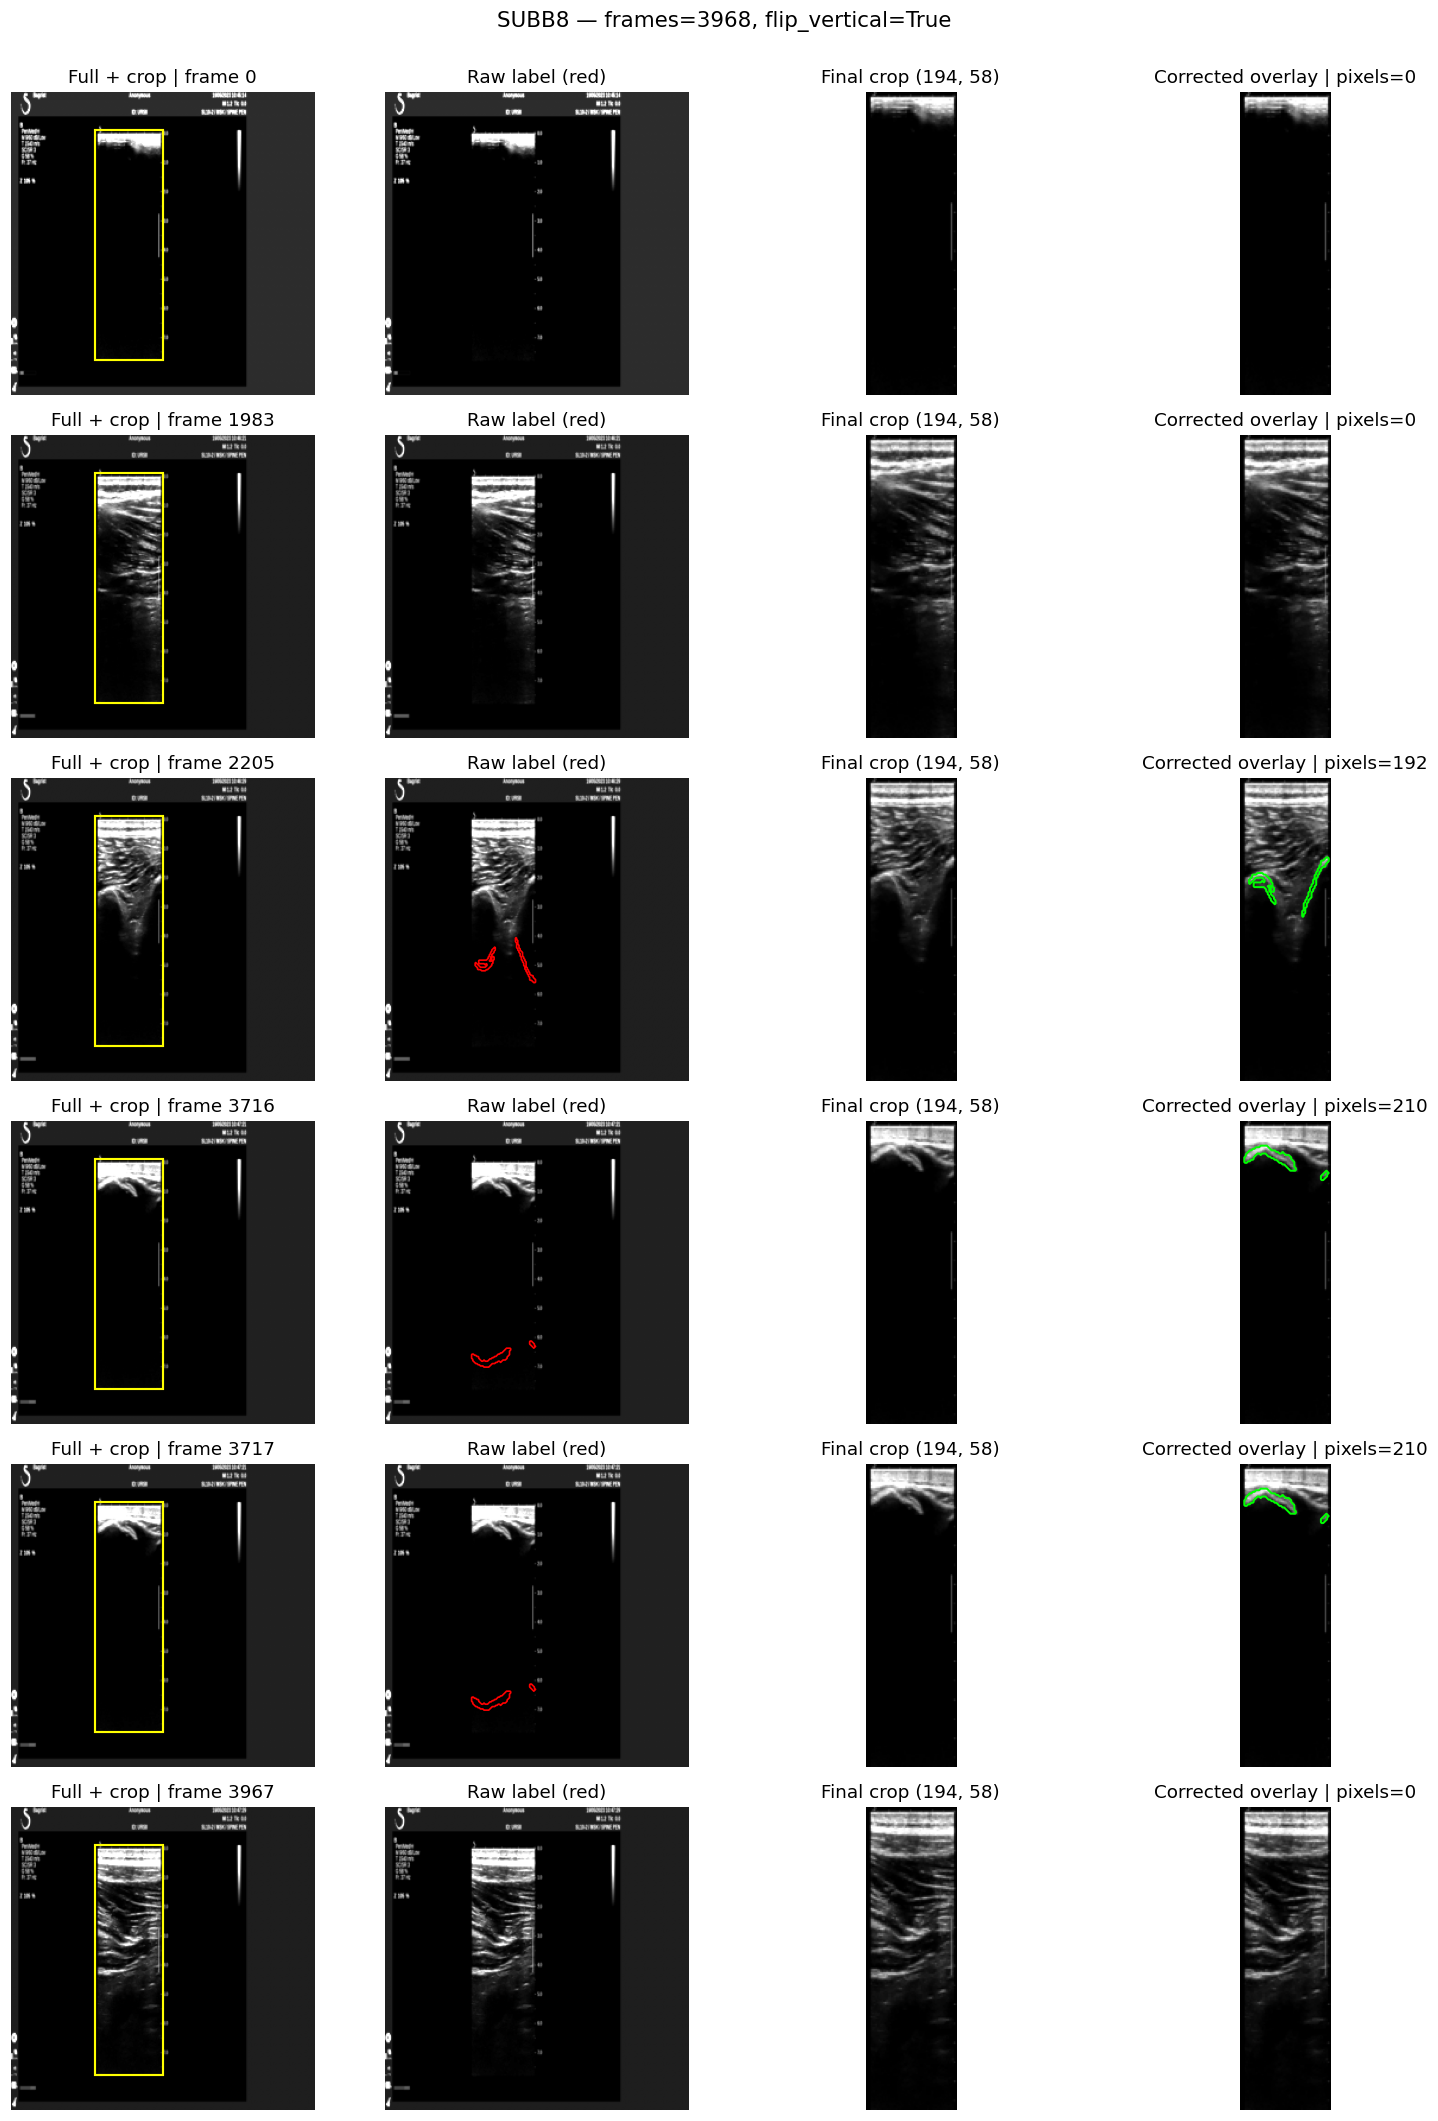

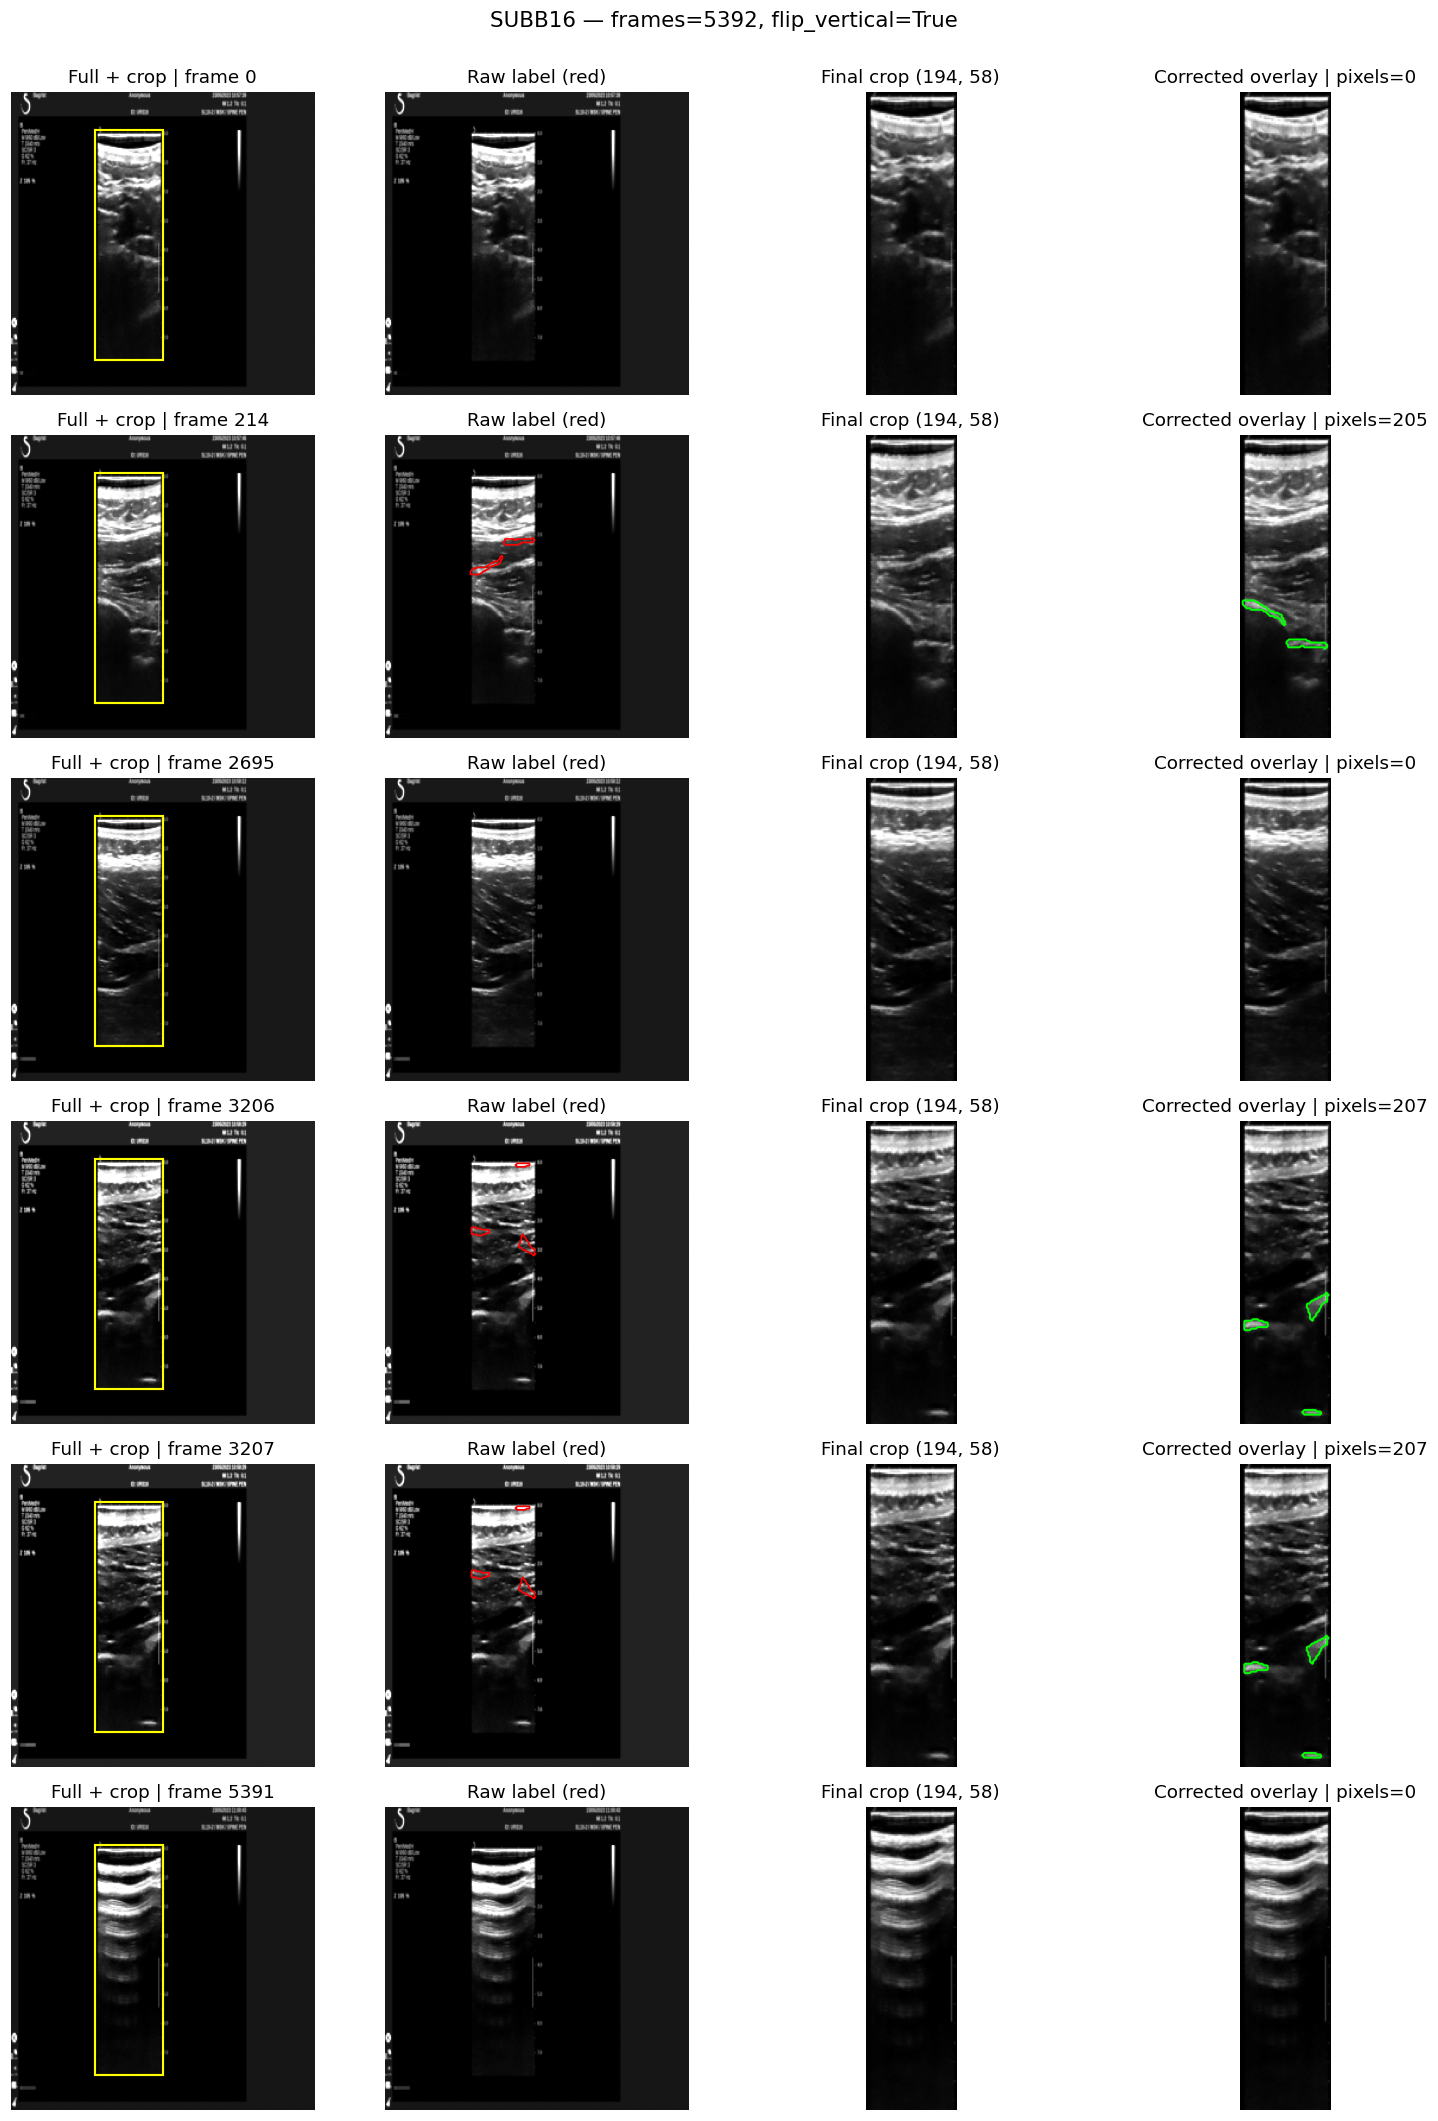

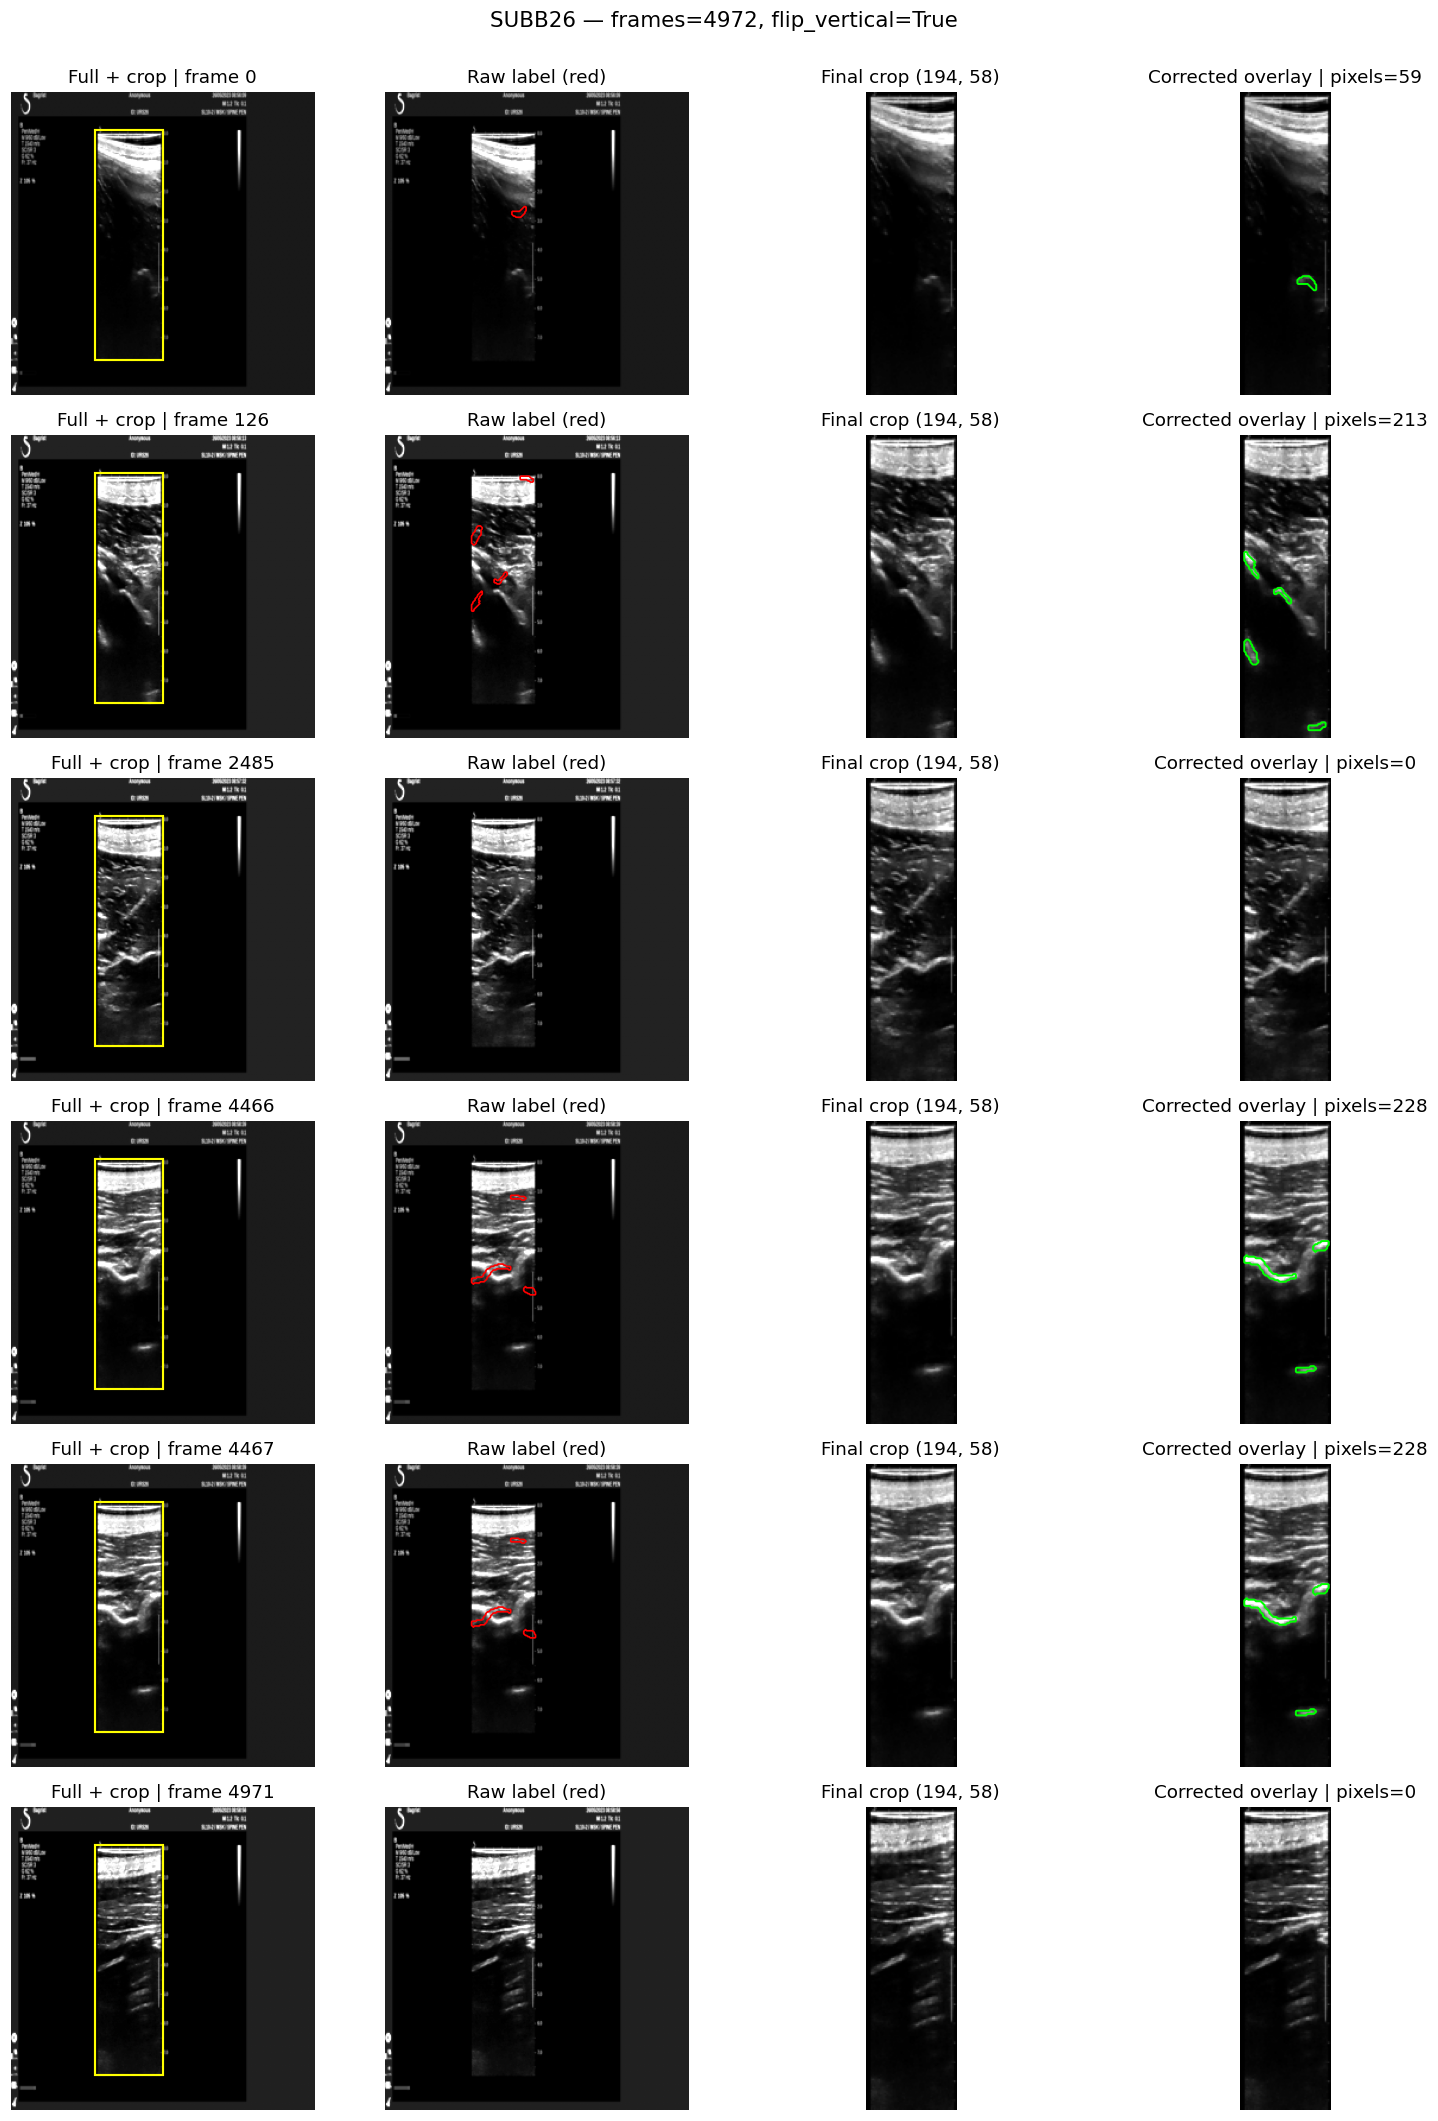

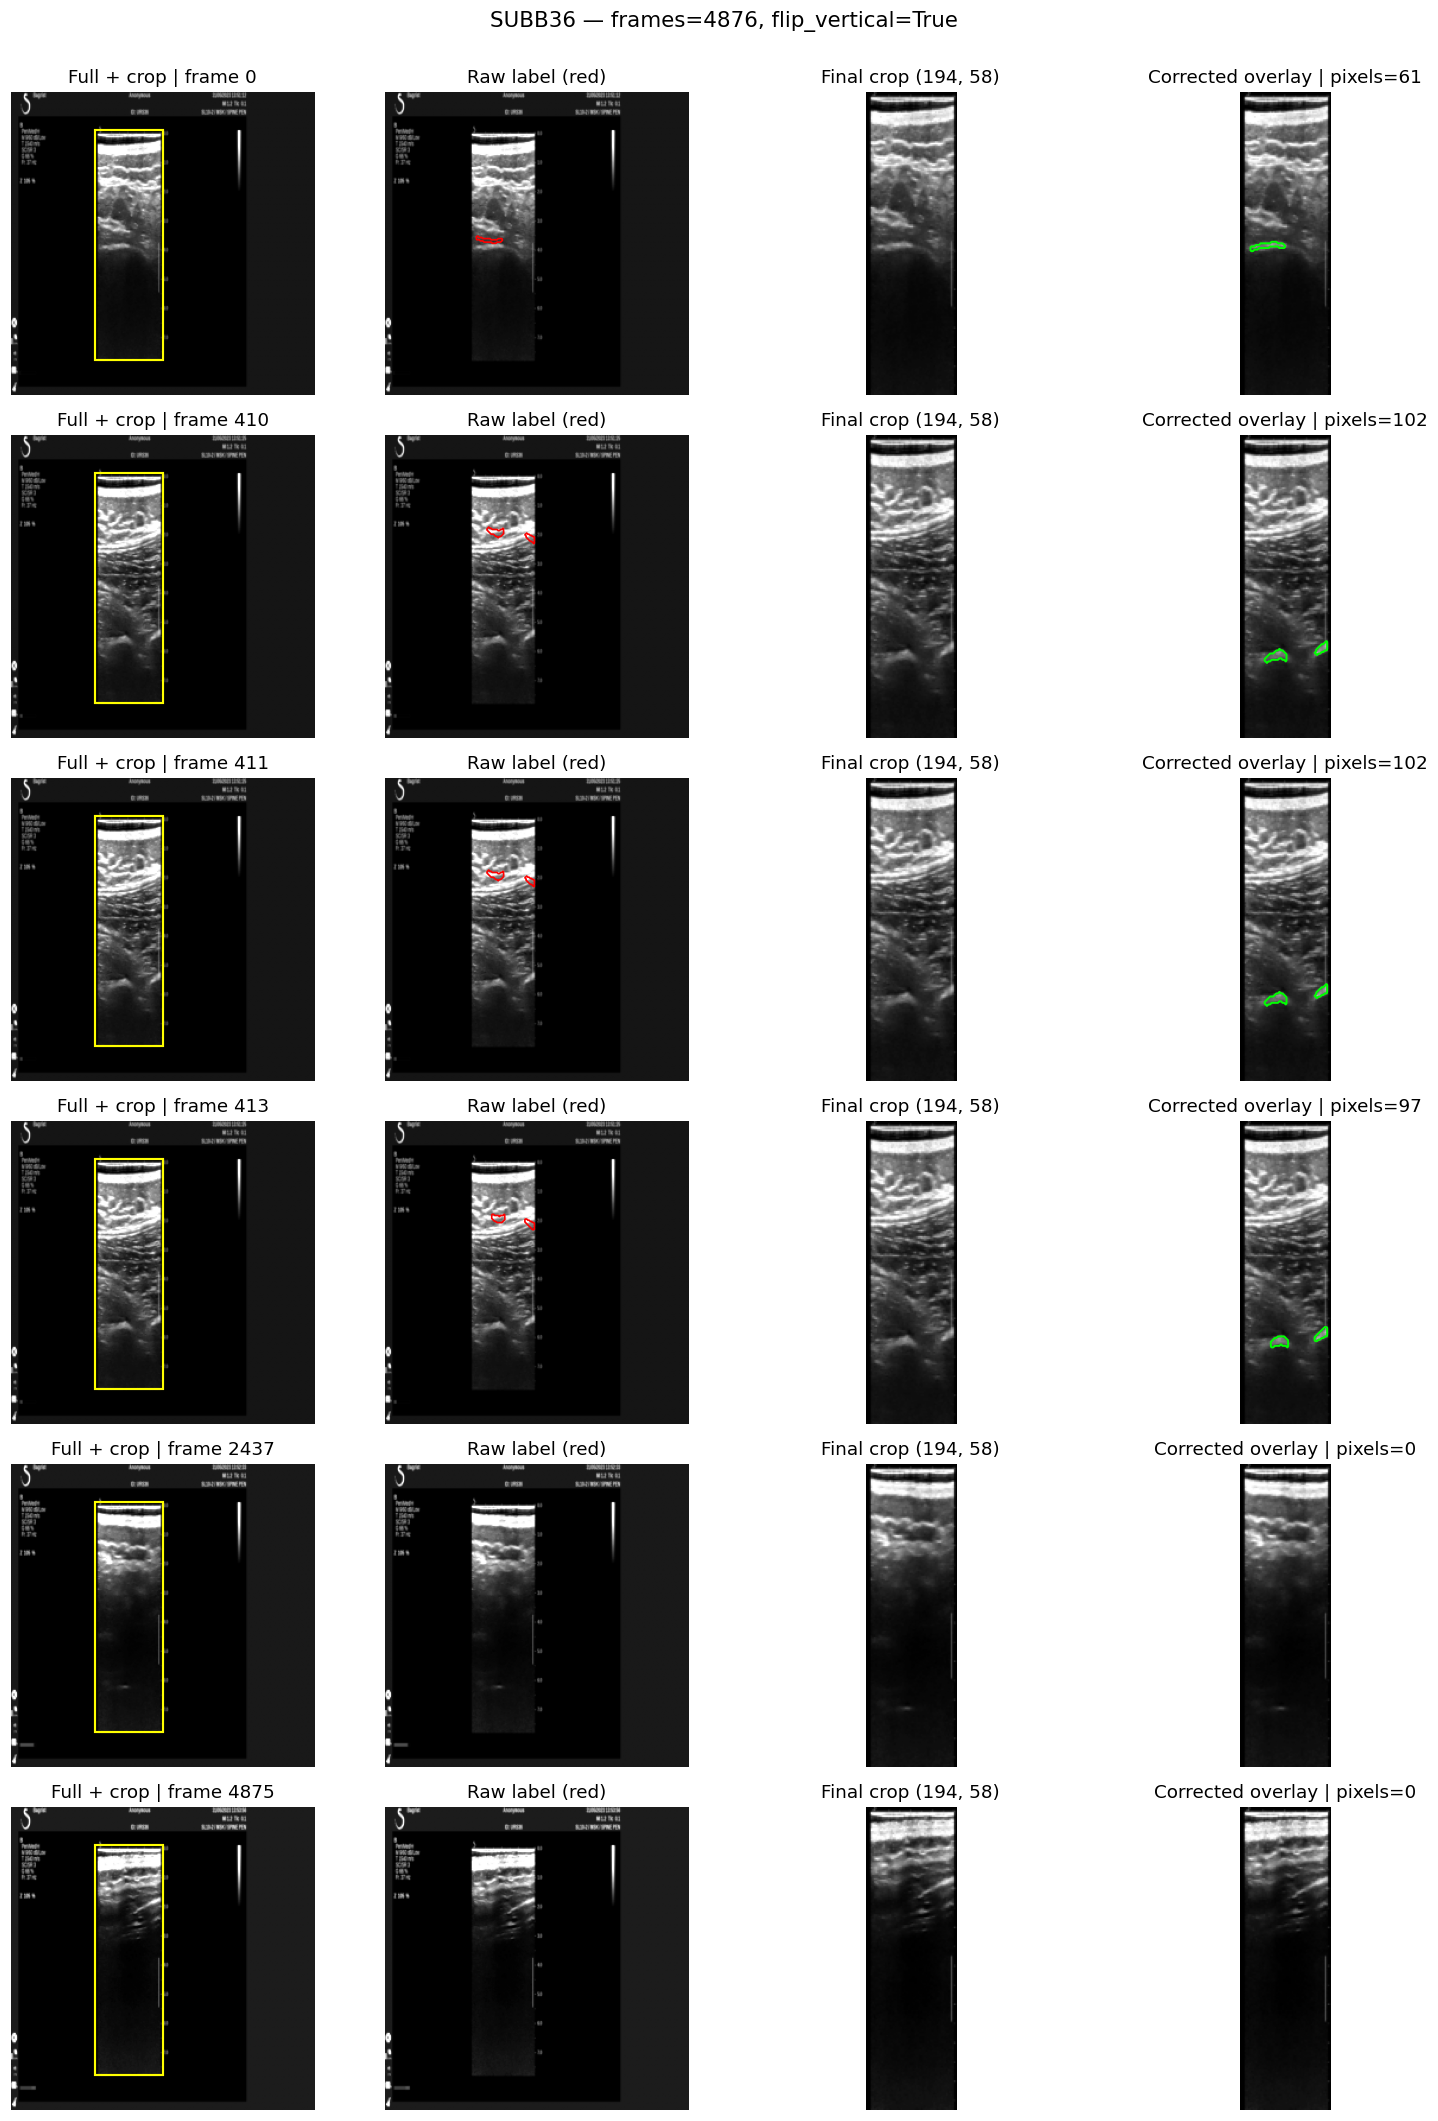

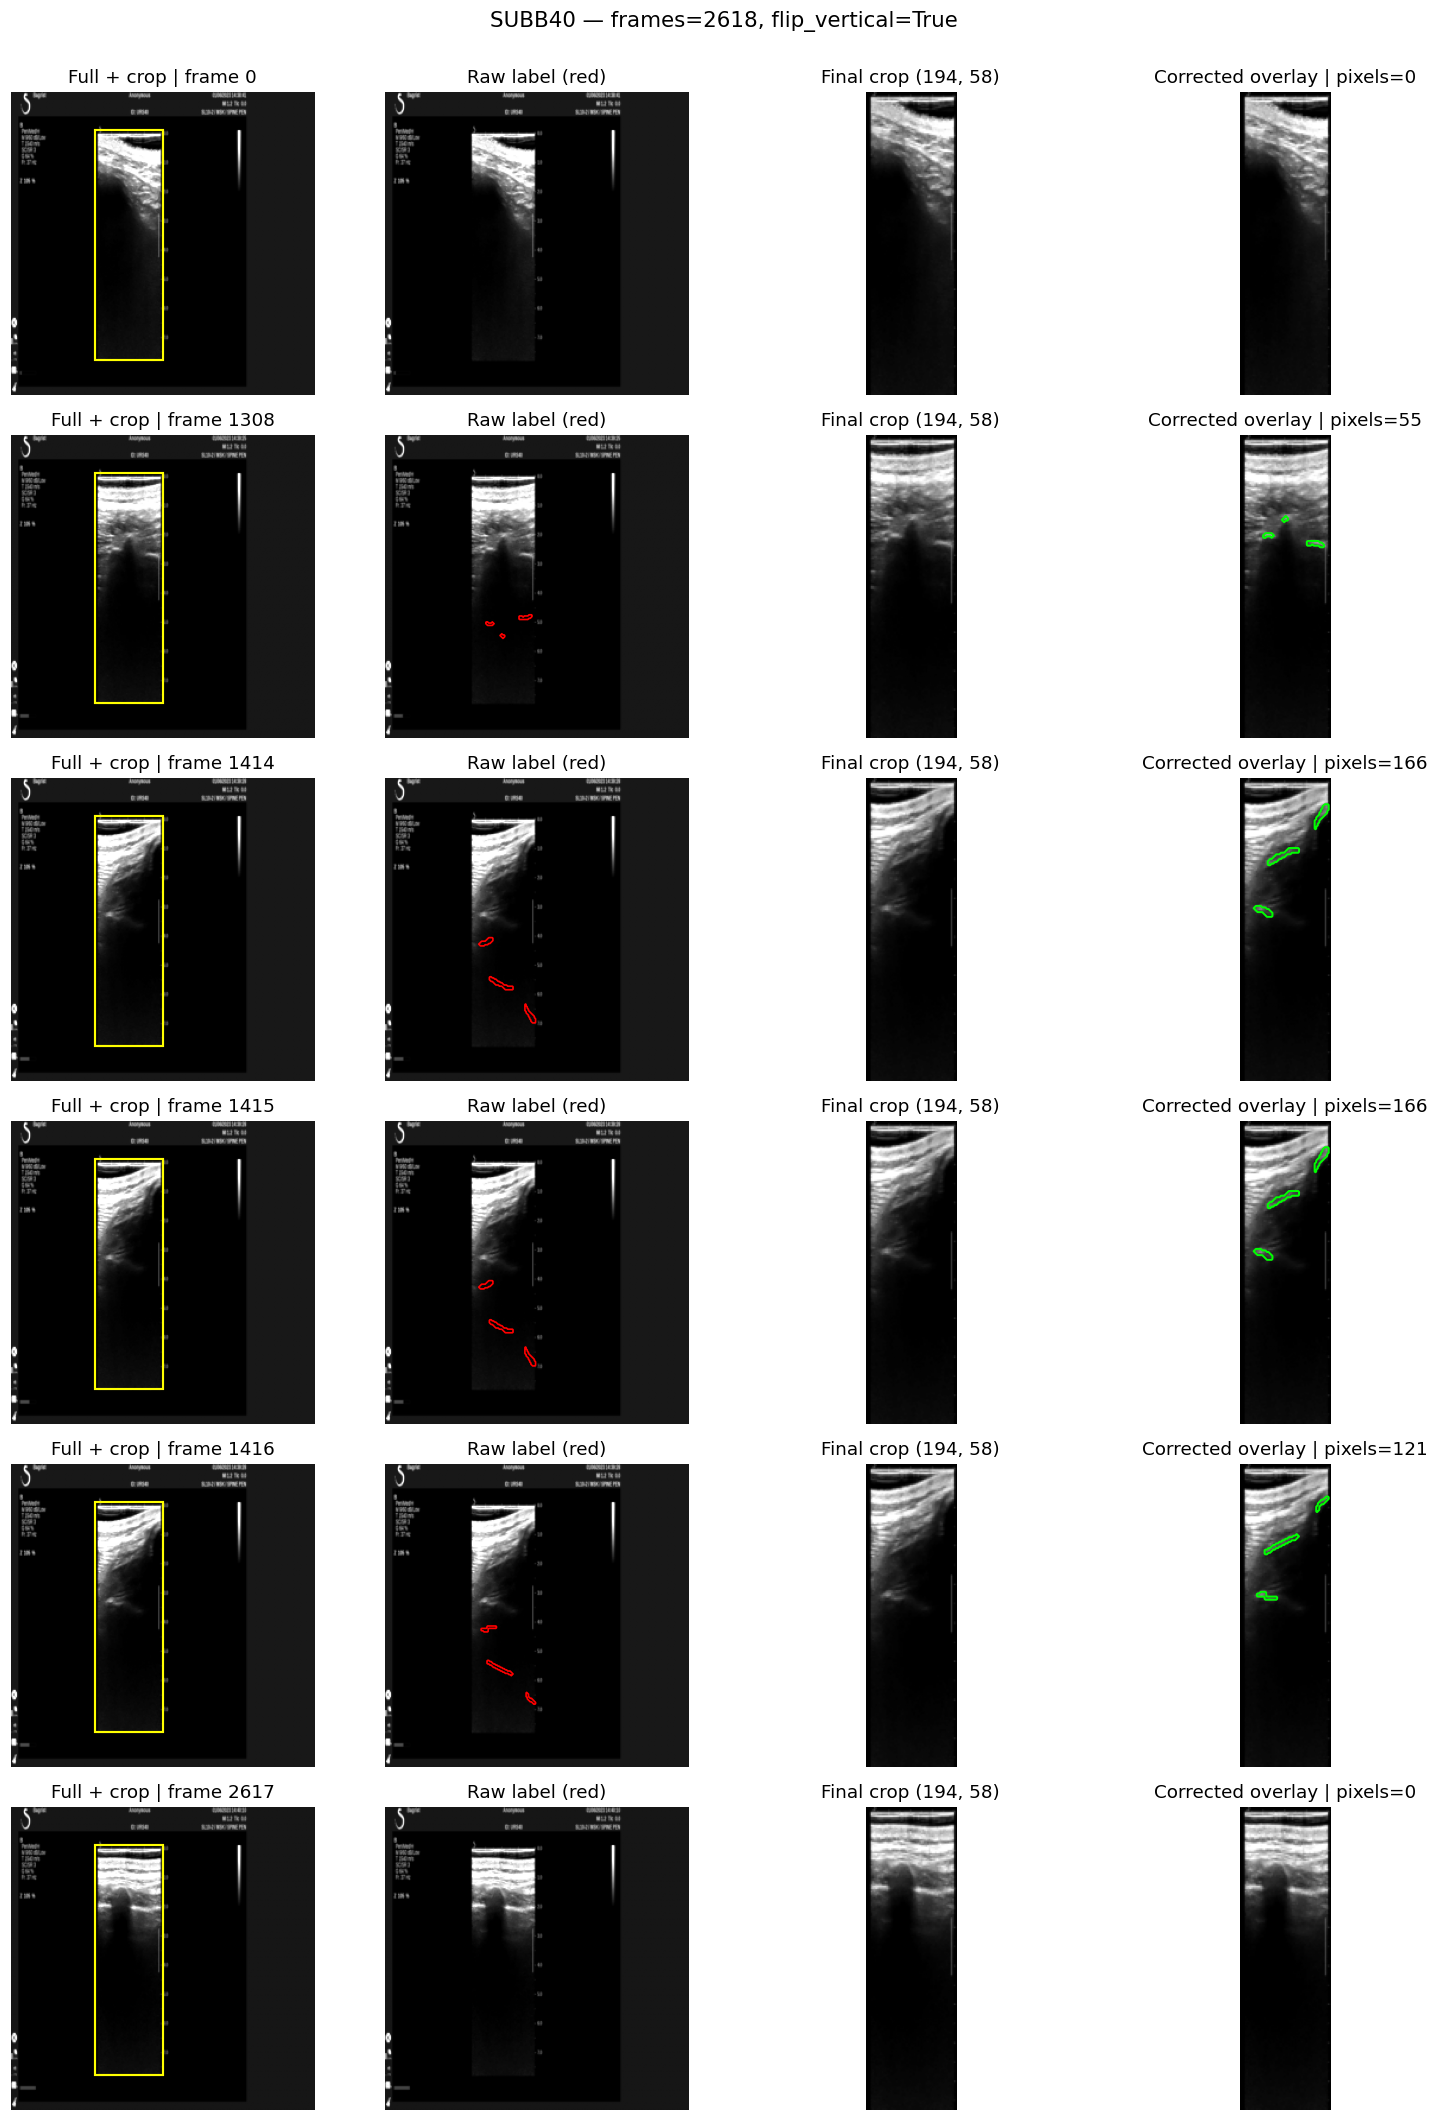

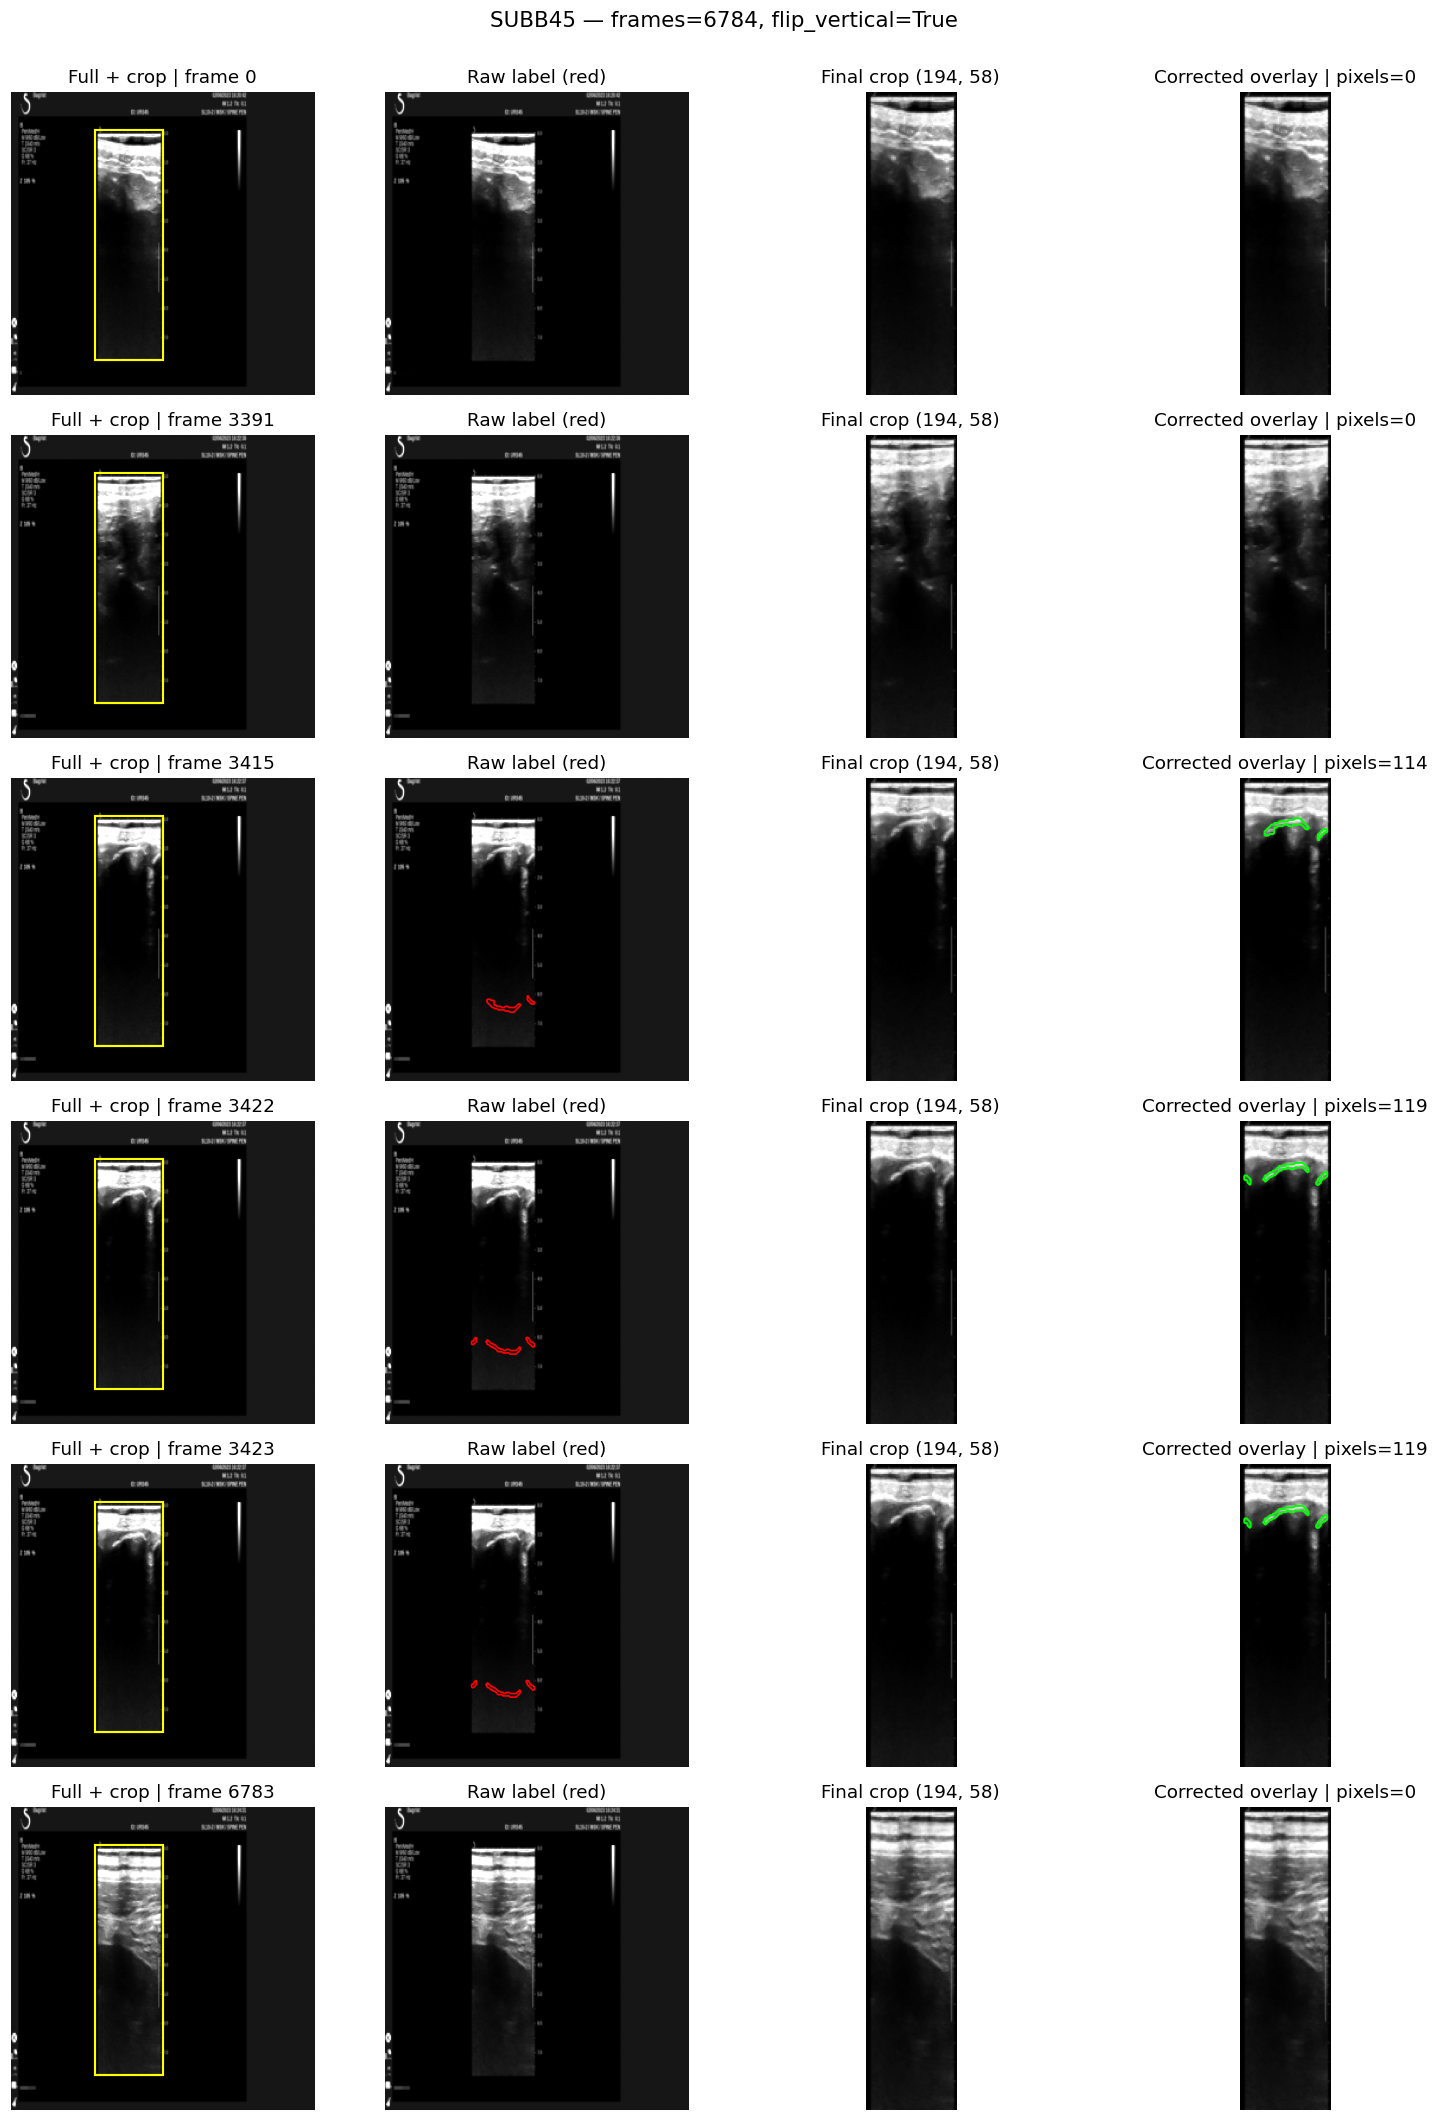

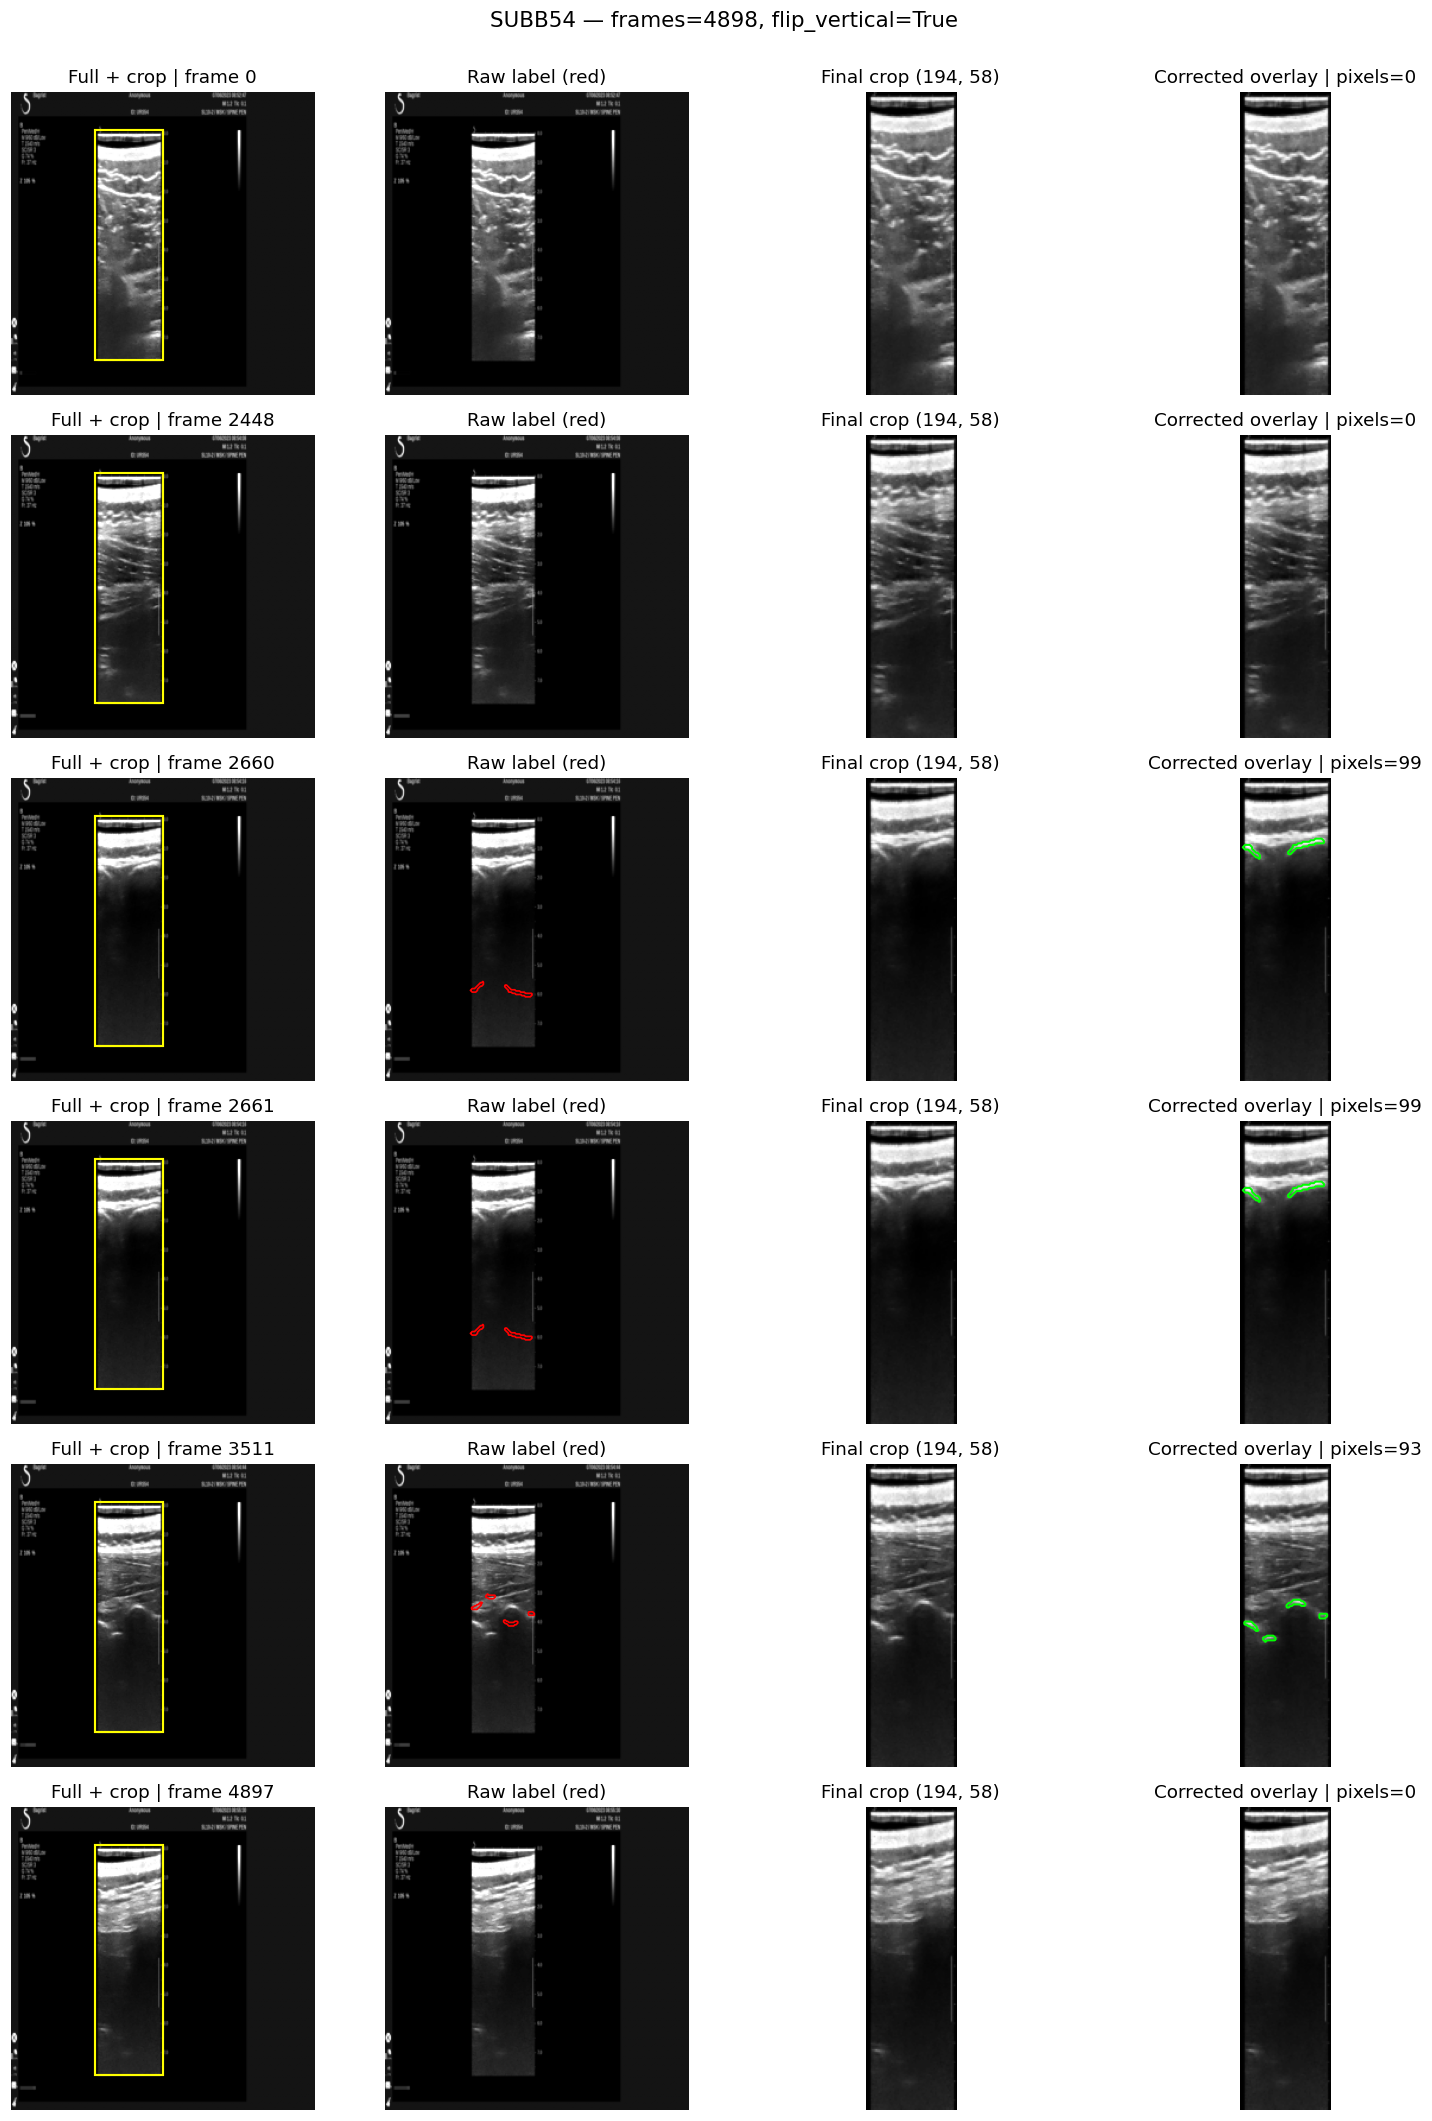

In [7]:
def choose_qa_frames(subject, n=QA_FRAMES_PER_SUBJECT):
    counts = MASK_PIXEL_COUNTS[subject]
    n_frames = len(counts)
    spread = np.linspace(0, n_frames - 1, max(2, n // 2), dtype=int)
    nonempty = np.flatnonzero(counts > 0)
    if len(nonempty):
        top = nonempty[np.argsort(counts[nonempty])[-max(2, n - len(spread)):]]
        chosen = np.unique(np.concatenate([spread, top]))
    else:
        chosen = np.unique(spread)
    if len(chosen) > n:
        chosen = chosen[np.linspace(0, len(chosen) - 1, n, dtype=int)]
    return np.sort(chosen)


def robust_limits(image):
    lo, hi = np.percentile(image, [1, 99])
    if hi <= lo:
        hi = lo + 1e-6
    return lo, hi


def plot_subject_qa(subject, n=QA_FRAMES_PER_SUBJECT):
    frames = choose_qa_frames(subject, n)
    cfg = SUBJECT_CONFIG[subject]
    c = cfg["crop"]
    fig, axes = plt.subplots(len(frames), 4, figsize=(14, 3.2 * len(frames)), squeeze=False)

    for row, idx in enumerate(frames):
        crop_img, crop_mask, full_img, raw_soft, corrected_soft = preprocess_frame(
            subject, int(idx), return_details=True
        )
        raw_mask = raw_soft >= infer_mask_threshold(subject)
        lo, hi = robust_limits(full_img)
        clo, chi = robust_limits(crop_img)

        axes[row, 0].imshow(full_img, cmap="gray", vmin=lo, vmax=hi)
        axes[row, 0].add_patch(Rectangle(
            (c["x1"], c["y1"]), c["x2"] - c["x1"], c["y2"] - c["y1"],
            edgecolor="yellow", facecolor="none", linewidth=1.4
        ))
        axes[row, 0].set_title(f"Full + crop | frame {idx}")

        axes[row, 1].imshow(full_img, cmap="gray", vmin=lo, vmax=hi)
        if raw_mask.any():
            axes[row, 1].contour(raw_mask.astype(float), levels=[0.5], colors="red", linewidths=1.1)
        axes[row, 1].set_title("Raw label (red)")

        axes[row, 2].imshow(crop_img, cmap="gray", vmin=clo, vmax=chi)
        axes[row, 2].set_title(f"Final crop {crop_img.shape}")

        axes[row, 3].imshow(crop_img, cmap="gray", vmin=clo, vmax=chi)
        if crop_mask.any():
            axes[row, 3].contour(crop_mask.astype(float), levels=[0.5], colors="lime", linewidths=1.3)
        axes[row, 3].set_title(f"Corrected overlay | pixels={int(crop_mask.sum())}")

        for ax in axes[row]:
            ax.axis("off")

    fig.suptitle(
        f"{subject} — frames={len(DATA[subject]['recordings'])}, "
        f"flip_vertical={cfg['flip_mask_vertical']}", y=1.002, fontsize=14
    )
    plt.tight_layout()
    plt.show()


for subject in SUBJECTS:
    plot_subject_qa(subject)

## 6. Optional focused orientation comparison

If a subject looks questionable, run this cell after changing `SUBJECT_TO_COMPARE`. It places the raw and vertically flipped masks side by side on the same image. Change `SUBJECT_CONFIG[subject]["flip_mask_vertical"]` only if the evidence is consistent across many frames.

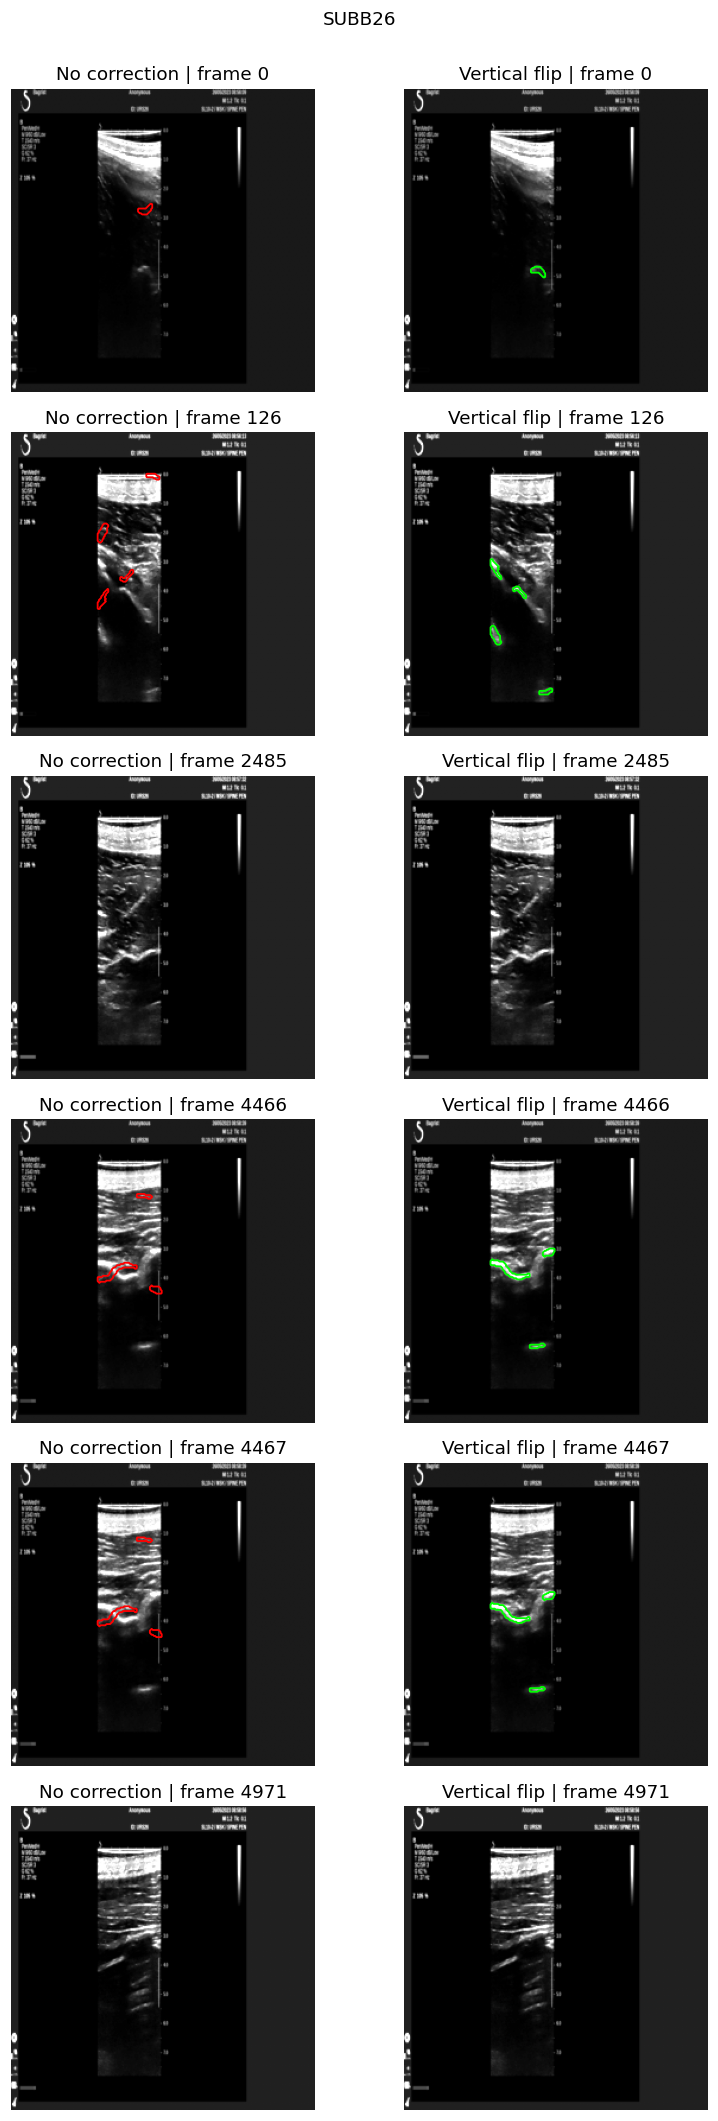

In [8]:
SUBJECT_TO_COMPARE = "SUBB26"

def compare_orientation(subject, n=6):
    frames = choose_qa_frames(subject, n)
    rec = DATA[subject]["recordings"]
    lab = DATA[subject]["labels"]
    threshold = infer_mask_threshold(subject)
    fig, axes = plt.subplots(len(frames), 2, figsize=(8, 3.2 * len(frames)), squeeze=False)
    for row, idx in enumerate(frames):
        image = squeeze_frame(rec[int(idx)]).astype(np.float32) / infer_image_scale(subject)
        raw = squeeze_frame(lab[int(idx)]) >= threshold
        flipped = np.flip(raw, axis=0)
        lo, hi = robust_limits(image)
        for col, (title, mask, color) in enumerate([
            ("No correction", raw, "red"), ("Vertical flip", flipped, "lime")
        ]):
            axes[row, col].imshow(image, cmap="gray", vmin=lo, vmax=hi)
            if mask.any():
                axes[row, col].contour(mask.astype(float), levels=[0.5], colors=color, linewidths=1.2)
            axes[row, col].set_title(f"{title} | frame {idx}")
            axes[row, col].axis("off")
    fig.suptitle(subject, y=1.002)
    plt.tight_layout()
    plt.show()

compare_orientation(SUBJECT_TO_COMPARE)

## 7. Confirmed preprocessing configuration

The common crop and vertical mask correction are already confirmed for all seven subjects, so export proceeds automatically. The QA plots remain as an integrity record.

In [9]:
# The transformation was already confirmed for all seven uploaded subjects.
# No manual approval switch is required in this one-click notebook.
print("Preprocessing configuration: confirmed for all seven subjects")


Preprocessing configuration: confirmed for all seven subjects


## 8. Chunked export

This creates one image array and one mask array per subject without holding a full subject in RAM. Metadata records source paths, frame counts, crop, orientation, scale, and threshold.

In [10]:
def export_subject(subject, output_root=OUTPUT_ROOT, chunk_size=CHUNK_SIZE):
    output_root.mkdir(parents=True, exist_ok=True)
    n = len(DATA[subject]["recordings"])
    c = SUBJECT_CONFIG[subject]["crop"]
    out_shape = (n, c["y2"] - c["y1"], c["x2"] - c["x1"])

    image_path = output_root / f"{subject}_images.npy"
    mask_path = output_root / f"{subject}_masks.npy"
    images_out = open_memmap(image_path, mode="w+", dtype=np.float32, shape=out_shape)
    masks_out = open_memmap(mask_path, mode="w+", dtype=np.uint8, shape=out_shape)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        for idx in range(start, end):
            images_out[idx], masks_out[idx] = preprocess_frame(subject, idx)
        images_out.flush()
        masks_out.flush()
        print(f"{subject}: {end}/{n}", end="\r")

    del images_out, masks_out
    metadata = {
        "subject": subject,
        "frames": n,
        "output_shape": list(out_shape),
        "image_dtype": "float32",
        "image_range": [0.0, 1.0],
        "mask_dtype": "uint8",
        "mask_values": [0, 1],
        "crop": c,
        "flip_mask_vertical": SUBJECT_CONFIG[subject]["flip_mask_vertical"],
        "image_scale": infer_image_scale(subject),
        "mask_threshold": infer_mask_threshold(subject),
        "source_recordings": str(FILE_PAIRS[subject][0]),
        "source_labels": str(FILE_PAIRS[subject][1]),
        "diagnostics": diagnostics.loc[subject].to_dict(),
    }
    metadata_path = output_root / f"{subject}_metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    print(f"{subject}: exported to {output_root}")
    return image_path, mask_path, metadata_path


exported_files = {subject: export_subject(subject) for subject in SUBJECTS}
diagnostics.to_csv(OUTPUT_ROOT / "all_subjects_diagnostics.csv")
inventory.to_csv(OUTPUT_ROOT / "all_subjects_inventory.csv")
print("All exports complete:", OUTPUT_ROOT)

SUBB8: exported to /kaggle/working/subb_preprocessed_194x58


SUBB16: exported to /kaggle/working/subb_preprocessed_194x58


SUBB26: exported to /kaggle/working/subb_preprocessed_194x58


SUBB36: exported to /kaggle/working/subb_preprocessed_194x58


SUBB40: exported to /kaggle/working/subb_preprocessed_194x58


SUBB45: exported to /kaggle/working/subb_preprocessed_194x58


SUBB54: exported to /kaggle/working/subb_preprocessed_194x58
All exports complete: /kaggle/working/subb_preprocessed_194x58


## 9. Verify saved arrays and plot exported samples

This final check reopens every exported array with memory mapping, verifies its shape/type/range, and plots three saved overlays per subject.

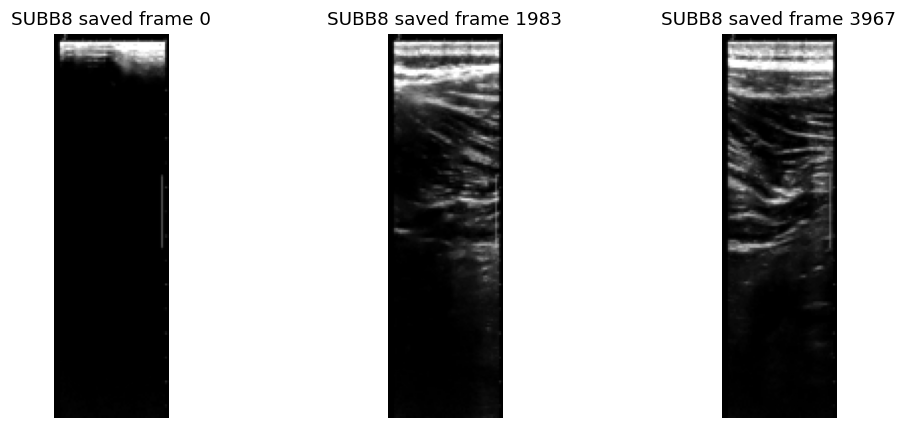

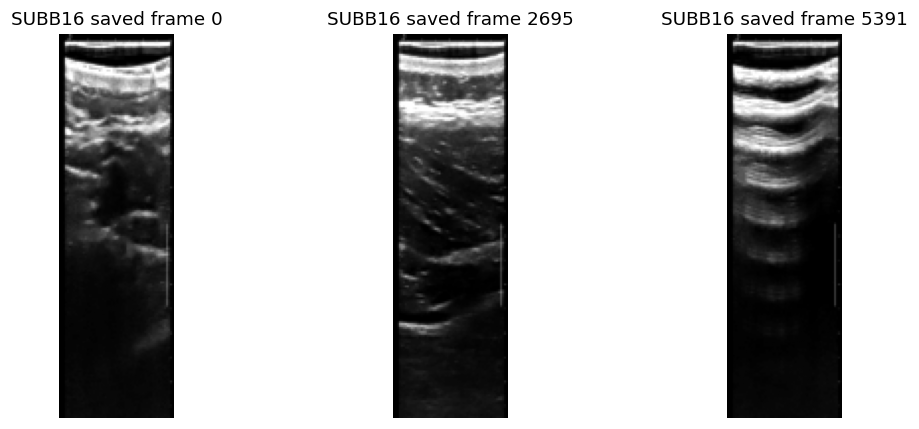

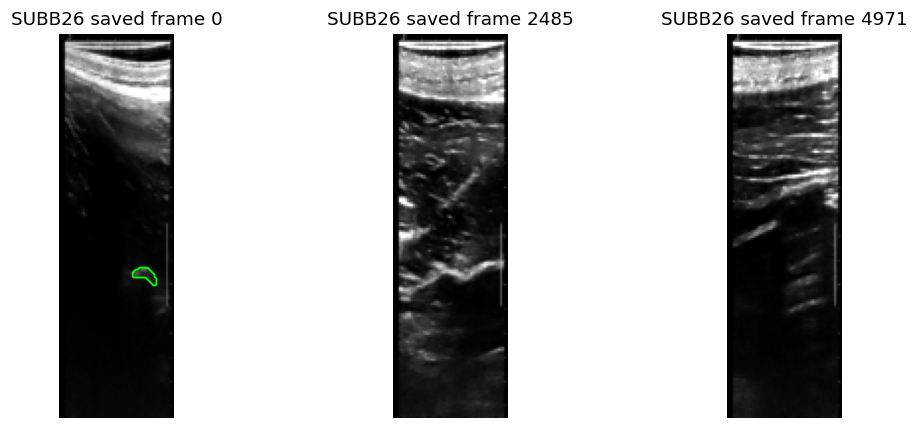

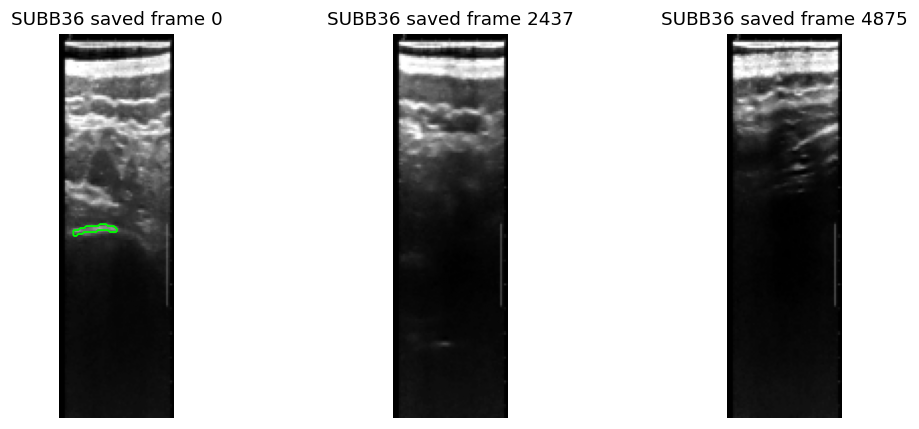

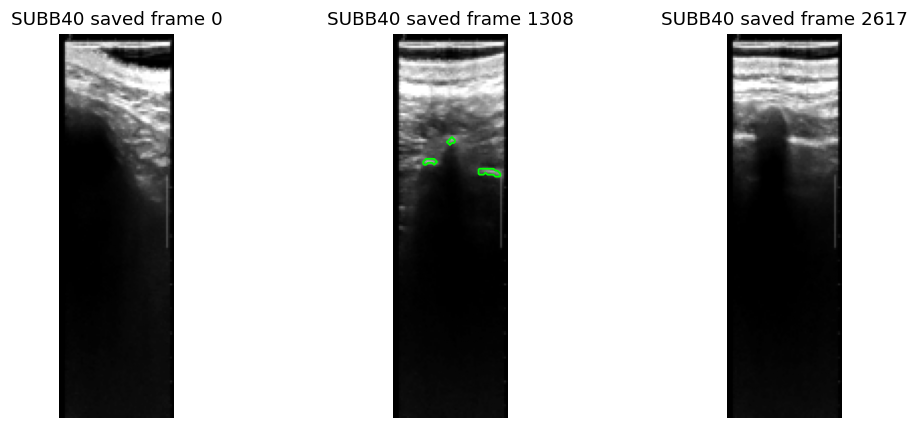

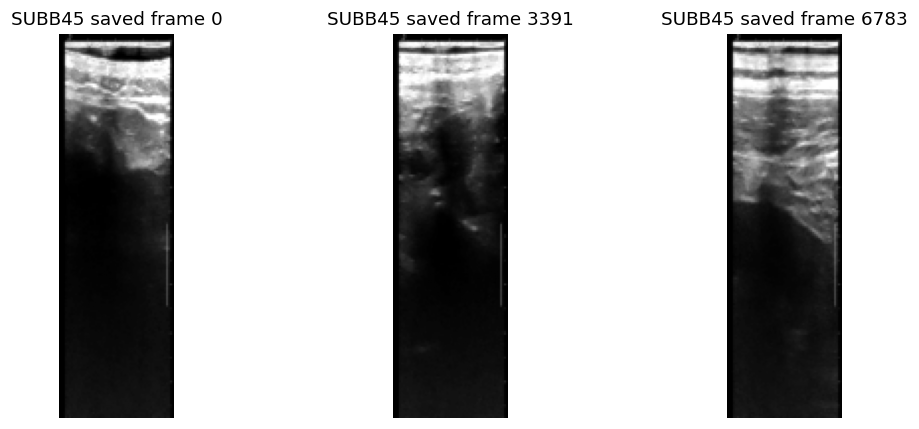

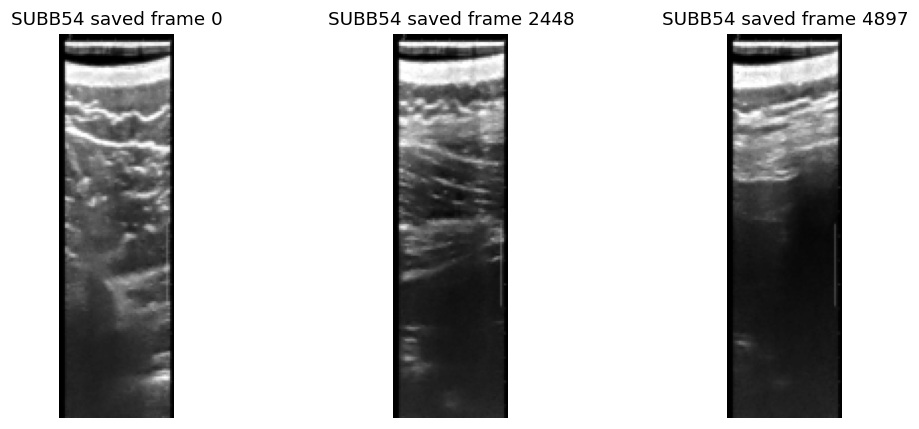

,saved_shape,status
subject,,
SUBB8,"(3968, 194, 58)",PASS
SUBB16,"(5392, 194, 58)",PASS
SUBB26,"(4972, 194, 58)",PASS
SUBB36,"(4876, 194, 58)",PASS
SUBB40,"(2618, 194, 58)",PASS
SUBB45,"(6784, 194, 58)",PASS
SUBB54,"(4898, 194, 58)",PASS


In [11]:
verification_rows = []
for subject in SUBJECTS:
    image_path, mask_path, _ = exported_files[subject]
    images = np.load(image_path, mmap_mode="r", allow_pickle=False)
    masks = np.load(mask_path, mmap_mode="r", allow_pickle=False)
    expected_frames = len(DATA[subject]["recordings"])
    assert images.shape == masks.shape == (expected_frames, EXPECTED_H, EXPECTED_W)
    assert images.dtype == np.float32 and masks.dtype == np.uint8

    idxs = np.unique(np.linspace(0, expected_frames - 1, 3, dtype=int))
    sample_images = np.asarray(images[idxs])
    sample_masks = np.asarray(masks[idxs])
    assert np.isfinite(sample_images).all()
    assert sample_images.min() >= 0 and sample_images.max() <= 1
    assert set(np.unique(sample_masks)).issubset({0, 1})

    verification_rows.append({"subject": subject, "saved_shape": str(images.shape), "status": "PASS"})
    fig, axes = plt.subplots(1, len(idxs), figsize=(3.6 * len(idxs), 4), squeeze=False)
    for ax, idx, image, mask in zip(axes[0], idxs, sample_images, sample_masks):
        lo, hi = robust_limits(image)
        ax.imshow(image, cmap="gray", vmin=lo, vmax=hi)
        if mask.any():
            ax.contour(mask.astype(float), levels=[0.5], colors="lime", linewidths=1.2)
        ax.set_title(f"{subject} saved frame {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

display(pd.DataFrame(verification_rows).set_index("subject"))

## Interpretation checklist

- `frames` must match between recordings and labels for every subject.
- The yellow crop rectangle must contain the complete ultrasound region you intend to retain.
- The final green contour must follow the target anatomy across early, middle, late, and high-annotation frames.
- `foreground_retained_percent` should ideally be at least 99%.
- Frequent mask contact with a crop edge is a warning that the crop may be too tight.
- If raw red contours align better than corrected green contours for one subject, set only that subject's `flip_mask_vertical` to `False`, rerun diagnostics/plots, and re-check.
- Do not confirm or export a subject based on shape equality alone.

# Part II — subject-wise model comparison

The cells below consume the arrays just exported to `/kaggle/working/subb_preprocessed_194x58`. No separate Kaggle Dataset is required when this notebook is run from top to bottom in one session.

The initial configuration runs no training. First complete preprocessing and inventory, then enable one smoke-test fold.


## Experimental design: automatic seven-fold comparison

Both methods use the same leave-one-subject-out manifest and shared evaluation code. Every execution runs folds `0–6`; there are no training or evaluation toggles. The held-out subject never contributes frames to its fold’s training data.


In [12]:
from pathlib import Path
import gc
import json
import os
import random
import re
import shutil
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
SUBJECTS = ["SUBB8", "SUBB16", "SUBB26", "SUBB36", "SUBB40", "SUBB45", "SUBB54"]
FOLDS_TO_RUN = list(range(7))

PROCESSED_ROOT_OVERRIDE = None
PREPROCESSING_OUTPUT = Path("/kaggle/working/subb_preprocessed_194x58")
WORK_ROOT = Path("/kaggle/working/subb_model_comparison")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# Basic U-Net: global batch is split equally across the two GPUs.
UNET_EPOCHS = 60
UNET_BATCH_SIZE = 16
UNET_STEPS_PER_EPOCH = 250
UNET_INITIAL_LR = 1e-3
UNET_POSITIVE_FRACTION = 0.70
UNET_BASE_FILTERS = 32

ORIGINAL_SHAPE = (194, 58)
MODEL_SHAPE = (208, 64)

NNUNET_DATASET_ID = 801
NNUNET_DATASET_NAME = "Dataset801_SUBBLumbarUS"
# Official shorter trainer: a one-session, compute-balanced Kaggle experiment.
NNUNET_TRAINER = "nnUNetTrainer_50epochs"
NNUNET_GPU_IDS = [0, 1]
NNUNET_AUGMENTATION_WORKERS_PER_FOLD = 2

def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

def detect_nvidia_gpus():
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        check=True, capture_output=True, text=True,
    )
    return [line.strip() for line in result.stdout.splitlines() if line.strip()]

seed_everything()
GPU_NAMES = detect_nvidia_gpus()
if len(GPU_NAMES) != 2:
    raise RuntimeError(
        f"This notebook requires Kaggle GPU T4 x2; detected {len(GPU_NAMES)} GPU(s): {GPU_NAMES}"
    )
print("Detected GPUs:", GPU_NAMES)
print("Folds scheduled:", FOLDS_TO_RUN)
print("Both models will run automatically.")


Detected GPUs: ['Tesla T4', 'Tesla T4']
Folds scheduled: [0, 1, 2, 3, 4, 5, 6]
Both models will run automatically.


## 1. Locate and validate processed arrays

The notebook accepts the files produced earlier: `{subject}_images.npy` and `{subject}_masks.npy`. It checks that frame counts and spatial dimensions match before creating any folds.

In [13]:
def discover_processed_root():
    if PROCESSED_ROOT_OVERRIDE is not None:
        root = Path(PROCESSED_ROOT_OVERRIDE)
        if not root.exists():
            raise FileNotFoundError(f"PROCESSED_ROOT_OVERRIDE does not exist: {root}")
        return root
    if PREPROCESSING_OUTPUT.exists():
        return PREPROCESSING_OUTPUT
    candidates = []
    for search_root in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not search_root.exists():
            continue
        for first_image in search_root.rglob(f"{SUBJECTS[0]}_images.npy"):
            candidate = first_image.parent
            complete = all(
                (candidate / f"{s}_images.npy").exists() and
                (candidate / f"{s}_masks.npy").exists()
                for s in SUBJECTS
            )
            if complete and candidate not in candidates:
                candidates.append(candidate)
    if len(candidates) != 1:
        raise FileNotFoundError(
            "Could not uniquely identify the processed-data folder. "
            f"Complete candidates: {candidates}. Set PROCESSED_ROOT_OVERRIDE explicitly."
        )
    return candidates[0]


PROCESSED_ROOT = discover_processed_root()
print("Processed root:", PROCESSED_ROOT)


def locate_one(subject, role):
    exact = PROCESSED_ROOT / f"{subject}_{role}.npy"
    if exact.exists():
        return exact
    matches = sorted(PROCESSED_ROOT.rglob(f"{subject}_{role}.npy"))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one {subject}_{role}.npy below {PROCESSED_ROOT}, found {len(matches)}"
        )
    return matches[0]


DATA = {}
inventory_rows = []
for subject in SUBJECTS:
    image_path = locate_one(subject, "images")
    mask_path = locate_one(subject, "masks")
    images = np.load(image_path, mmap_mode="r", allow_pickle=False)
    masks = np.load(mask_path, mmap_mode="r", allow_pickle=False)
    if images.shape != masks.shape:
        raise ValueError(f"{subject}: image/mask mismatch {images.shape} vs {masks.shape}")
    if images.ndim != 3 or images.shape[1:] != ORIGINAL_SHAPE:
        raise ValueError(f"{subject}: expected (N,194,58), got {images.shape}")
    if not np.issubdtype(images.dtype, np.floating):
        warnings.warn(f"{subject}: expected floating images, found {images.dtype}")
    DATA[subject] = {
        "images": images, "masks": masks,
        "image_path": image_path, "mask_path": mask_path,
    }
    inventory_rows.append({
        "subject": subject, "frames": len(images), "shape": str(images.shape),
        "image_dtype": str(images.dtype), "mask_dtype": str(masks.dtype),
    })

inventory = pd.DataFrame(inventory_rows).set_index("subject")
display(inventory)
print("Total frames:", int(inventory.frames.sum()))

Processed root: /kaggle/working/subb_preprocessed_194x58


,frames,shape,image_dtype,mask_dtype
subject,,,,
SUBB8,3968,"(3968, 194, 58)",float32,uint8
SUBB16,5392,"(5392, 194, 58)",float32,uint8
SUBB26,4972,"(4972, 194, 58)",float32,uint8
SUBB36,4876,"(4876, 194, 58)",float32,uint8
SUBB40,2618,"(2618, 194, 58)",float32,uint8
SUBB45,6784,"(6784, 194, 58)",float32,uint8
SUBB54,4898,"(4898, 194, 58)",float32,uint8


Total frames: 33508


## 2. Shared LOSO fold manifest

The held-out subject is the evaluation subject. Its frames never enter the training sampler. The manifest is written once and reused by both pipelines.

In [14]:
FOLDS = []
for fold, test_subject in enumerate(SUBJECTS):
    train_subjects = [s for s in SUBJECTS if s != test_subject]
    FOLDS.append({
        "fold": fold,
        "train_subjects": train_subjects,
        "test_subject": test_subject,
        "train_frames": int(sum(len(DATA[s]["images"]) for s in train_subjects)),
        "test_frames": int(len(DATA[test_subject]["images"])),
    })

fold_table = pd.DataFrame(FOLDS)
display(fold_table)

manifest_path = WORK_ROOT / "loso_folds.json"
manifest_path.write_text(json.dumps(FOLDS, indent=2), encoding="utf-8")
print("Saved:", manifest_path)

,fold,train_subjects,test_subject,train_frames,test_frames
0,0,"[SUBB16, SUBB26, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB8,29540,3968
1,1,"[SUBB8, SUBB26, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB16,28116,5392
2,2,"[SUBB8, SUBB16, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB26,28536,4972
3,3,"[SUBB8, SUBB16, SUBB26, SUBB40, SUBB45, SUBB54]",SUBB36,28632,4876
4,4,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB45, SUBB54]",SUBB40,30890,2618
5,5,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB40, SUBB54]",SUBB45,26724,6784
6,6,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB40, SUBB45]",SUBB54,28610,4898


Saved: /kaggle/working/subb_model_comparison/loso_folds.json


## 3. Shared padding and evaluation functions

Primary metrics are computed once per held-out subject by aggregating all its pixels. Frame-wise Dice is secondary. Empty-ground-truth frames are reported explicitly, and the mean non-empty-frame Dice excludes empty ground truth.

HD95 is calculated only when both ground truth and prediction are non-empty. Missed positive frames and false-positive empty frames are counted separately.

In [15]:
def pad_to_model_shape(array2d):
    h, w = array2d.shape
    target_h, target_w = MODEL_SHAPE
    if (h, w) != ORIGINAL_SHAPE:
        raise ValueError(f"Expected {ORIGINAL_SHAPE}, got {(h, w)}")
    top = (target_h - h) // 2
    bottom = target_h - h - top
    left = (target_w - w) // 2
    right = target_w - w - left
    return np.pad(array2d, ((top, bottom), (left, right)), mode="constant"), (top, bottom, left, right)


def unpad_from_model_shape(array2d):
    h, w = ORIGINAL_SHAPE
    top = (MODEL_SHAPE[0] - h) // 2
    left = (MODEL_SHAPE[1] - w) // 2
    return array2d[top:top+h, left:left+w]


def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)
    tp = int(np.logical_and(y_true, y_pred).sum())
    fp = int(np.logical_and(~y_true, y_pred).sum())
    fn = int(np.logical_and(y_true, ~y_pred).sum())
    tn = int(np.logical_and(~y_true, ~y_pred).sum())
    return tp, fp, fn, tn


def overlap_from_counts(tp, fp, fn):
    dice_den = 2 * tp + fp + fn
    iou_den = tp + fp + fn
    dice = 1.0 if dice_den == 0 else 2 * tp / dice_den
    iou = 1.0 if iou_den == 0 else tp / iou_den
    precision = 1.0 if tp + fp == 0 and tp + fn == 0 else tp / max(tp + fp, 1)
    recall = 1.0 if tp + fn == 0 else tp / (tp + fn)
    return dice, iou, precision, recall


def hd95_binary(y_true, y_pred):
    from scipy.ndimage import distance_transform_edt
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)
    if not y_true.any() or not y_pred.any():
        return np.nan
    # Surface pixels are foreground pixels with at least one background neighbor.
    from scipy.ndimage import binary_erosion
    true_surface = y_true ^ binary_erosion(y_true)
    pred_surface = y_pred ^ binary_erosion(y_pred)
    dist_to_true = distance_transform_edt(~true_surface)
    dist_to_pred = distance_transform_edt(~pred_surface)
    distances = np.concatenate([dist_to_true[pred_surface], dist_to_pred[true_surface]])
    return float(np.percentile(distances, 95)) if len(distances) else np.nan


def evaluate_subject(subject, prediction_masks, model_name):
    truth = np.asarray(DATA[subject]["masks"] > 0, dtype=bool)
    pred = np.asarray(prediction_masks > 0, dtype=bool)
    if pred.shape != truth.shape:
        raise ValueError(f"{subject}: prediction shape {pred.shape} != truth {truth.shape}")

    frame_rows = []
    for idx in range(len(truth)):
        tp, fp, fn, tn = confusion_counts(truth[idx], pred[idx])
        dice, iou, precision, recall = overlap_from_counts(tp, fp, fn)
        gt_nonempty, pred_nonempty = bool(truth[idx].any()), bool(pred[idx].any())
        frame_rows.append({
            "model": model_name, "subject": subject, "frame": idx,
            "gt_nonempty": gt_nonempty, "pred_nonempty": pred_nonempty,
            "dice": dice, "iou": iou, "precision": precision, "recall": recall,
            "hd95_pixels": hd95_binary(truth[idx], pred[idx]),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        })
    frames = pd.DataFrame(frame_rows)
    tp, fp, fn, tn = confusion_counts(truth, pred)
    dice, iou, precision, recall = overlap_from_counts(tp, fp, fn)
    positive = frames.gt_nonempty
    both_positive = frames.gt_nonempty & frames.pred_nonempty
    summary = {
        "model": model_name, "subject": subject, "frames": len(truth),
        "subject_micro_dice": dice, "subject_micro_iou": iou,
        "subject_micro_precision": precision, "subject_micro_recall": recall,
        "mean_frame_dice_all": float(frames.dice.mean()),
        "mean_frame_dice_gt_nonempty": float(frames.loc[positive, "dice"].mean()) if positive.any() else np.nan,
        "mean_hd95_both_nonempty_pixels": float(frames.loc[both_positive, "hd95_pixels"].mean()) if both_positive.any() else np.nan,
        "gt_nonempty_frames": int(positive.sum()),
        "missed_positive_frames": int((frames.gt_nonempty & ~frames.pred_nonempty).sum()),
        "false_positive_empty_frames": int((~frames.gt_nonempty & frames.pred_nonempty).sum()),
    }
    return frames, summary


test = np.zeros(ORIGINAL_SHAPE, dtype=np.uint8)
padded, pads = pad_to_model_shape(test)
assert padded.shape == MODEL_SHAPE and unpad_from_model_shape(padded).shape == ORIGINAL_SHAPE
print("Padding test passed; pads (top,bottom,left,right):", pads)

Padding test passed; pads (top,bottom,left,right): (7, 7, 3, 3)


# Part III — official nnU-Net v2

nnU-Net is a framework, not merely another hand-written U-Net architecture. It fingerprints the dataset, plans preprocessing and topology, trains its own configuration, and applies its own inference rules.

Each subject is saved as one NIfTI volume with shape `(frames, 194, 58)`. The `2d` configuration treats its frames as 2D training slices while the case identity remains the subject. Therefore the custom split can hold out a complete subject.

## Dependency audit

The packages were installed before NumPy/pandas were imported. This cell records and verifies the exact versions used by the experiment.


In [16]:
from importlib.metadata import version

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("nnU-Net:", version("nnunetv2"))
print("SimpleITK:", version("SimpleITK"))
assert np.__version__ == "2.0.2"
assert pd.__version__ == "2.2.2"
assert version("nnunetv2") == "2.8.1"
print("Dependency audit passed")


NumPy: 2.0.2
pandas: 2.2.2
nnU-Net: 2.8.1
SimpleITK: 2.5.5
Dependency audit passed


## 8. Configure nnU-Net directories and convert the seven subjects

The already-normalized float images are preserved as float32 NIfTI data. Masks remain integer labels `{0,1}`. The very large through-plane spacing discourages treating frames as a physically isotropic 3D volume; training explicitly uses the `2d` configuration.

In [17]:
NNUNET_BASE = WORK_ROOT / "nnunet_workspace"
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"
NNUNET_PREPROCESSED = NNUNET_BASE / "nnUNet_preprocessed"
NNUNET_RESULTS = NNUNET_BASE / "nnUNet_results"

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
os.environ["nnUNet_results"] = str(NNUNET_RESULTS)

RAW_DATASET_DIR = NNUNET_RAW / NNUNET_DATASET_NAME


def prepare_nnunet_raw_dataset():
    try:
        import SimpleITK as sitk
    except ImportError as exc:
        raise ImportError("Install SimpleITK/nnunetv2 using the previous cell first") from exc

    images_tr = RAW_DATASET_DIR / "imagesTr"
    labels_tr = RAW_DATASET_DIR / "labelsTr"
    images_ts = RAW_DATASET_DIR / "imagesTs"
    for directory in [images_tr, labels_tr, images_ts]:
        directory.mkdir(parents=True, exist_ok=True)

    for subject in SUBJECTS:
        image_volume = np.asarray(DATA[subject]["images"], dtype=np.float32)
        label_volume = np.asarray(DATA[subject]["masks"] > 0, dtype=np.uint8)
        image_itk = sitk.GetImageFromArray(image_volume)  # z,y,x = frames,height,width
        label_itk = sitk.GetImageFromArray(label_volume)
        spacing = (1.0, 1.0, 999.0)  # x,y,z
        image_itk.SetSpacing(spacing)
        label_itk.SetSpacing(spacing)
        sitk.WriteImage(image_itk, str(images_tr / f"{subject}_0000.nii.gz"), True)
        sitk.WriteImage(label_itk, str(labels_tr / f"{subject}.nii.gz"), True)
        print(subject, image_volume.shape, "written")

    dataset_json = {
        "channel_names": {"0": "ultrasound"},
        "labels": {"background": 0, "target": 1},
        "numTraining": len(SUBJECTS),
        "file_ending": ".nii.gz",
        "overwrite_image_reader_writer": "SimpleITKIO",
    }
    (RAW_DATASET_DIR / "dataset.json").write_text(
        json.dumps(dataset_json, indent=2), encoding="utf-8"
    )
    print("nnU-Net raw dataset:", RAW_DATASET_DIR)


prepare_nnunet_raw_dataset()


SUBB8 (3968, 194, 58) written


SUBB16 (5392, 194, 58) written


SUBB26 (4972, 194, 58) written


SUBB36 (4876, 194, 58) written


SUBB40 (2618, 194, 58) written


SUBB45 (6784, 194, 58) written


SUBB54 (4898, 194, 58) written
nnU-Net raw dataset: /kaggle/working/subb_model_comparison/nnunet_workspace/nnUNet_raw/Dataset801_SUBBLumbarUS


## Fingerprint, 2D-only planning, preprocessing, and LOSO splits

The previous failure occurred because the default planner constructed irrelevant 3D configurations before saving its valid 2D plan. This cell deliberately separates the official fingerprint and preprocessing commands and inserts a 2D-only planner between them. It asserts that the resulting plans file contains exactly one configuration: `2d`.


In [18]:
def run_checked(command, env=None):
    command = list(map(str, command))
    print("Running:", " ".join(command))
    subprocess.run(command, check=True, env=(env or os.environ.copy()))

def create_2d_only_plans():
    """Create the standard nnU-Net 2D plan without constructing any 3D plan."""
    from batchgenerators.utilities.file_and_folder_operations import join
    from nnunetv2.experiment_planning.experiment_planners.default_experiment_planner import ExperimentPlanner
    from nnunetv2.preprocessing.resampling.default_resampling import compute_new_shape
    from nnunetv2.paths import nnUNet_preprocessed, nnUNet_raw

    class ExperimentPlanner2DOnly(ExperimentPlanner):
        def plan_experiment(self):
            cache = {}
            transpose_forward, transpose_backward = self.determine_transpose()
            fullres_spacing = self.determine_fullres_target_spacing()
            fullres_spacing_transposed = fullres_spacing[transpose_forward]

            new_shapes = [
                compute_new_shape(shape, spacing, fullres_spacing)
                for spacing, shape in zip(
                    self.dataset_fingerprint["spacings"],
                    self.dataset_fingerprint["shapes_after_crop"],
                )
            ]
            new_median_shape = np.median(new_shapes, axis=0)
            new_median_shape_transposed = new_median_shape[transpose_forward]
            approximate_n_voxels_dataset = float(
                np.prod(new_median_shape_transposed, dtype=np.float64)
                * self.dataset_json["numTraining"]
            )

            plan_2d = self.get_plans_for_configuration(
                fullres_spacing_transposed[1:],
                new_median_shape_transposed[1:],
                self.generate_data_identifier("2d"),
                approximate_n_voxels_dataset,
                cache,
            )
            plan_2d["batch_dice"] = True

            median_spacing = np.median(
                self.dataset_fingerprint["spacings"], axis=0
            )[transpose_forward]
            median_shape = np.median(
                self.dataset_fingerprint["shapes_after_crop"], axis=0
            )[transpose_forward]

            shutil.copy(
                join(nnUNet_raw, self.dataset_name, "dataset.json"),
                join(nnUNet_preprocessed, self.dataset_name, "dataset.json"),
            )
            plans = {
                "dataset_name": self.dataset_name,
                "plans_name": self.plans_identifier,
                "original_median_spacing_after_transp": [float(i) for i in median_spacing],
                "original_median_shape_after_transp": [int(round(i)) for i in median_shape],
                "image_reader_writer": self.determine_reader_writer().__name__,
                "transpose_forward": [int(i) for i in transpose_forward],
                "transpose_backward": [int(i) for i in transpose_backward],
                "configurations": {"2d": plan_2d},
                "experiment_planner_used": self.__class__.__name__,
                "label_manager": "LabelManager",
                "foreground_intensity_properties_per_channel": self.dataset_fingerprint[
                    "foreground_intensity_properties_per_channel"
                ],
            }
            self.plans = plans
            self.save_plans(plans)
            return plans

    planner = ExperimentPlanner2DOnly(
        NNUNET_DATASET_ID,
        gpu_memory_target_in_gb=8,
        plans_name="nnUNetPlans",
    )
    plans = planner.plan_experiment()
    if set(plans["configurations"]) != {"2d"}:
        raise RuntimeError(f"Expected a 2D-only plan, got {plans['configurations'].keys()}")
    print("2D-only plan created:", plans["configurations"]["2d"]["patch_size"])
    return plans

preprocessed_dataset = NNUNET_PREPROCESSED / NNUNET_DATASET_NAME
# Remove any incomplete plan left by a previous attempt in the same Kaggle session.
if preprocessed_dataset.exists():
    shutil.rmtree(preprocessed_dataset)

run_checked([
    "nnUNetv2_extract_fingerprint", "-d", NNUNET_DATASET_ID,
    "--verify_dataset_integrity",
])
plans = create_2d_only_plans()
run_checked([
    "nnUNetv2_preprocess", "-d", NNUNET_DATASET_ID,
    "-c", "2d", "-np", "4",
])

plans_path = preprocessed_dataset / "nnUNetPlans.json"
if not plans_path.exists():
    raise FileNotFoundError(f"Missing 2D plans file: {plans_path}")
preprocessed_2d = preprocessed_dataset / "nnUNetPlans_2d"
if not preprocessed_2d.exists():
    raise FileNotFoundError(f"Missing preprocessed 2D data: {preprocessed_2d}")

nnunet_splits = []
for fold in FOLDS:
    nnunet_splits.append({
        "train": fold["train_subjects"],
        "val": [fold["test_subject"]],
    })
split_path = preprocessed_dataset / "splits_final.json"
split_path.write_text(json.dumps(nnunet_splits, indent=2), encoding="utf-8")
print("Custom LOSO splits written:", split_path)


Running: nnUNetv2_extract_fingerprint -d 801 --verify_dataset_integrity


Dataset801_SUBBLumbarUS
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer



####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer


Extracting dataset fingerprint:   0%|          | 0/7 [00:00<?, ?it/s]

Extracting dataset fingerprint:  14%|█▍        | 1/7 [00:16<01:36, 16.08s/it]

...

Preprocessing cases:  57%|█████▋    | 4/7 [00:29<00:15,  5.29s/it]

Preprocessing cases:  71%|███████▏  | 5/7 [00:38<00:13,  6.85s/it]

Preprocessing cases:  86%|████████▌ | 6/7 [00:41<00:05,  5.44s/it]

Preprocessing cases: 100%|██████████| 7/7 [00:43<00:00,  6.17s/it]


Custom LOSO splits written: /kaggle/working/subb_model_comparison/nnunet_workspace/nnUNet_preprocessed/Dataset801_SUBBLumbarUS/splits_final.json


## 10. Audit nnU-Net split file before training

This cell refuses to proceed if a held-out subject appears in its training list or the split does not exactly match the baseline manifest.

In [19]:
def audit_nnunet_splits():
    split_path = NNUNET_PREPROCESSED / NNUNET_DATASET_NAME / "splits_final.json"
    splits = json.loads(split_path.read_text(encoding="utf-8"))
    if len(splits) != len(FOLDS):
        raise ValueError(f"Expected {len(FOLDS)} folds, found {len(splits)}")
    for expected, actual in zip(FOLDS, splits):
        train, val = set(actual["train"]), set(actual["val"])
        if train != set(expected["train_subjects"]) or val != {expected["test_subject"]}:
            raise ValueError(f"Fold {expected['fold']} does not match shared LOSO manifest")
        if train & val:
            raise ValueError(f"Fold {expected['fold']} contains train/validation leakage")
    print("PASS: nnU-Net splits exactly match all seven subject-wise folds")
    return splits


if (NNUNET_PREPROCESSED / NNUNET_DATASET_NAME / "splits_final.json").exists():
    audit_nnunet_splits()
else:
    print("Split file not present yet; complete planning first.")

PASS: nnU-Net splits exactly match all seven subject-wise folds


## Train all seven nnU-Net folds on both T4 GPUs

`nnUNetTrainer_50epochs` is an official nnU-Net training-length variant chosen so the complete two-model, seven-fold experiment can run in one Kaggle session. Fold 0 runs alone first to initialize nnU-Net’s unpacked cache. The remaining folds run in pairs, one process on each T4.


In [20]:
def nnunet_command(fold_index):
    return [
        "nnUNetv2_train", str(NNUNET_DATASET_ID), "2d", str(fold_index),
        "-tr", NNUNET_TRAINER, "--npz",
    ]

def train_nnunet_fold_on_gpu(fold_index, gpu_id):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
    env["nnUNet_n_proc_DA"] = str(NNUNET_AUGMENTATION_WORKERS_PER_FOLD)
    env["OMP_NUM_THREADS"] = str(NNUNET_AUGMENTATION_WORKERS_PER_FOLD)
    env["MKL_NUM_THREADS"] = str(NNUNET_AUGMENTATION_WORKERS_PER_FOLD)
    env["PYTHONUNBUFFERED"] = "1"
    command = nnunet_command(fold_index)
    print(f"Starting nnU-Net fold {fold_index} on GPU {gpu_id}: {' '.join(command)}")
    return subprocess.Popen(command, env=env)

def run_nnunet_pair(fold_indices):
    processes = []
    for gpu_id, fold_index in zip(NNUNET_GPU_IDS, fold_indices):
        processes.append((fold_index, gpu_id, train_nnunet_fold_on_gpu(fold_index, gpu_id)))
    failures = []
    for fold_index, gpu_id, process in processes:
        return_code = process.wait()
        if return_code != 0:
            failures.append((fold_index, gpu_id, return_code))
    if failures:
        raise RuntimeError(f"nnU-Net fold failures: {failures}")

audit_nnunet_splits()
# First fold alone: safely initializes/unpacks the shared preprocessed cache.
run_nnunet_pair([0])
# Remaining folds use both T4s concurrently.
for pair in ([1, 2], [3, 4], [5, 6]):
    run_nnunet_pair(pair)
print("All seven nnU-Net folds completed")


PASS: nnU-Net splits exactly match all seven subject-wise folds
Starting nnU-Net fold 0 on GPU 0: nnUNetv2_train 801 2d 0 -tr nnUNetTrainer_50epochs --npz



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################



Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################



2026-09-01 09:52:27.788071: Using torch.compile...


2026-09-01 09:52:31.054838: do_dummy_2d_data_aug: False
2026-09-01 09:52:31.055454: Using splits from existing split file: /kaggle/working/subb_model_comparison/nnunet_workspace/nnUNet_preprocessed/Dataset801_SUBBLumbarUS/splits_final.json
2026-09-01 09:52:31.055862: The split file contains 7 splits.
2026-09-01 09:52:31.056063: Desired fold for training: 0
2026-09-01 09:52:31.056257: This split has 6 training and 1 validation cases.
using pin_memory on device 0


...

2026-09-01 21:39:28.459089: train_loss -0.8192
2026-09-01 21:39:28.459862: val_loss -0.3198
2026-09-01 21:39:28.460157: Pseudo dice [np.float32(0.3592)]
2026-09-01 21:39:28.460536: Epoch time: 232.89 s


2026-09-01 21:39:31.605436: 
2026-09-01 21:39:31.606117: Epoch 42
2026-09-01 21:39:31.606888: Current learning rate: 0.00192


2026-09-01 21:42:37.631622: train_loss -0.8179
2026-09-01 21:42:37.632146: val_loss -0.2578
2026-09-01 21:42:37.634773: Pseudo dice [np.float32(0.2805)]
2026-09-01 21:42:37.635101: Epoch time: 228.45 s


2026-09-01 21:42:40.561023: 
2026-09-01 21:42:40.563879: Epoch 43
2026-09-01 21:42:40.564151: Current learning rate: 0.0017


2026-09-01 21:43:20.351690: train_loss -0.8199
2026-09-01 21:43:20.355204: val_loss -0.3122
2026-09-01 21:43:20.356095: Pseudo dice [np.float32(0.3525)]
2026-09-01 21:43:20.357136: Epoch time: 228.75 s


## 12. Locate nnU-Net out-of-fold predictions and evaluate them

nnU-Net writes each fold's validation segmentation under its fold directory. The loader checks that the predicted subject is the correct held-out case and that its original `(frames,194,58)` shape is restored.

In [ ]:
NNUNET_COMPARISON_ROOT = WORK_ROOT / "nnunet_evaluation"
NNUNET_COMPARISON_ROOT.mkdir(parents=True, exist_ok=True)


def find_nnunet_fold_dir(fold_index):
    matches = sorted(NNUNET_RESULTS.rglob(f"fold_{fold_index}"))
    matches = [p for p in matches if p.is_dir() and "__2d" in str(p.parent)]
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected one 2d fold_{fold_index} directory, found {matches}")
    return matches[0]


def load_nnunet_validation_prediction(fold_index, subject):
    import SimpleITK as sitk
    fold_dir = find_nnunet_fold_dir(fold_index)
    candidates = [
        fold_dir / "validation" / f"{subject}.nii.gz",
        fold_dir / "validation_raw" / f"{subject}.nii.gz",
    ]
    prediction_path = next((p for p in candidates if p.exists()), None)
    if prediction_path is None:
        recursive = list(fold_dir.rglob(f"{subject}.nii.gz"))
        if len(recursive) != 1:
            raise FileNotFoundError(f"Could not uniquely locate {subject} prediction in {fold_dir}")
        prediction_path = recursive[0]
    prediction = sitk.GetArrayFromImage(sitk.ReadImage(str(prediction_path))).astype(np.uint8)
    expected = DATA[subject]["masks"].shape
    if prediction.shape != expected:
        raise ValueError(f"{subject}: nnU-Net prediction {prediction.shape}, expected {expected}")
    return prediction, prediction_path


nnunet_summaries = []
for fold_index in FOLDS_TO_RUN:
    subject = FOLDS[fold_index]["test_subject"]
    pred, pred_path = load_nnunet_validation_prediction(fold_index, subject)
    frames, summary = evaluate_subject(subject, pred, "nnunet_v2")
    summary["fold"] = fold_index
    summary["prediction_path"] = str(pred_path)
    frames.to_csv(NNUNET_COMPARISON_ROOT / f"fold_{fold_index}_{subject}_frame_metrics.csv", index=False)
    nnunet_summaries.append(summary)
nnunet_summary_df = pd.DataFrame(nnunet_summaries).sort_values("fold")
nnunet_summary_df.to_csv(NNUNET_COMPARISON_ROOT / "loso_subject_summary.csv", index=False)
display(nnunet_summary_df)


# Part IV — dual-GPU basic 2D U-Net

## Subject-balanced training sampler

Each training subject contributes equally per epoch even if subjects have different frame counts. Within each subject, the sampler targets a fixed positive-mask fraction. This avoids allowing the largest recording or abundant empty masks to dominate optimization.

Only horizontal flipping and image-intensity perturbations are used. Vertical flipping is deliberately excluded because depth direction has anatomical meaning.

In [ ]:
POSITIVE_INDICES = {}
EMPTY_INDICES = {}
for subject in SUBJECTS:
    masks = DATA[subject]["masks"]
    counts = np.zeros(len(masks), dtype=np.int64)
    for start in range(0, len(masks), 256):
        end = min(start + 256, len(masks))
        counts[start:end] = np.asarray(masks[start:end]).sum(axis=(1, 2))
    POSITIVE_INDICES[subject] = np.flatnonzero(counts > 0)
    EMPTY_INDICES[subject] = np.flatnonzero(counts == 0)
    print(subject, "positive=", len(POSITIVE_INDICES[subject]), "empty=", len(EMPTY_INDICES[subject]))

In [ ]:
import tensorflow as tf

physical_gpus = tf.config.list_physical_devices("GPU")
if len(physical_gpus) != 2:
    raise RuntimeError(f"TensorFlow expected 2 GPUs, detected: {physical_gpus}")
for gpu in physical_gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

tf.keras.utils.set_random_seed(SEED)
UNET_STRATEGY = tf.distribute.MirroredStrategy()
if UNET_STRATEGY.num_replicas_in_sync != 2:
    raise RuntimeError(
        f"MirroredStrategy expected 2 replicas, got {UNET_STRATEGY.num_replicas_in_sync}"
    )
if UNET_BATCH_SIZE % UNET_STRATEGY.num_replicas_in_sync != 0:
    raise ValueError("UNET_BATCH_SIZE must be divisible by the number of GPUs")
print("Basic U-Net replicas:", UNET_STRATEGY.num_replicas_in_sync)
print("Global batch:", UNET_BATCH_SIZE, "| per-GPU batch:", UNET_BATCH_SIZE // 2)

class SubjectBalancedSequence(tf.keras.utils.Sequence):
    def __init__(self, subjects, batch_size, steps_per_epoch, positive_fraction=0.7,
                 augment=True, seed=42, **kwargs):
        super().__init__(**kwargs)
        self.subjects = list(subjects)
        self.batch_size = int(batch_size)
        self.steps = int(steps_per_epoch)
        self.positive_fraction = float(positive_fraction)
        self.augment = bool(augment)
        self.rng = np.random.default_rng(seed)
        self.references = []
        self.on_epoch_end()

    def __len__(self):
        return self.steps

    def _sample_subject(self, subject, n):
        positive = POSITIVE_INDICES[subject]
        empty = EMPTY_INDICES[subject]
        n_pos = int(round(n * self.positive_fraction)) if len(positive) else 0
        n_empty = n - n_pos if len(empty) else 0
        if not len(empty): n_pos = n
        if not len(positive): n_empty = n
        refs = []
        if n_pos:
            refs += [(subject, int(i)) for i in self.rng.choice(positive, n_pos, replace=len(positive) < n_pos)]
        if n_empty:
            refs += [(subject, int(i)) for i in self.rng.choice(empty, n_empty, replace=len(empty) < n_empty)]
        return refs

    def on_epoch_end(self):
        total = self.steps * self.batch_size
        per_subject = int(np.ceil(total / len(self.subjects)))
        refs = []
        for subject in self.subjects:
            refs.extend(self._sample_subject(subject, per_subject))
        self.rng.shuffle(refs)
        self.references = refs[:total]

    def __getitem__(self, batch_index):
        refs = self.references[batch_index*self.batch_size:(batch_index+1)*self.batch_size]
        x = np.zeros((len(refs), *MODEL_SHAPE, 1), dtype=np.float32)
        y = np.zeros_like(x)
        for j, (subject, idx) in enumerate(refs):
            image = np.asarray(DATA[subject]["images"][idx], dtype=np.float32)
            mask = np.asarray(DATA[subject]["masks"][idx] > 0, dtype=np.float32)
            if self.augment and self.rng.random() < 0.5:
                image, mask = np.fliplr(image).copy(), np.fliplr(mask).copy()
            if self.augment:
                gamma = self.rng.uniform(0.85, 1.15)
                gain = self.rng.uniform(0.9, 1.1)
                image = np.clip(gain * np.power(np.clip(image, 0, 1), gamma), 0, 1)
                if self.rng.random() < 0.3:
                    image = np.clip(image + self.rng.normal(0, 0.01, image.shape), 0, 1)
            image, _ = pad_to_model_shape(image)
            mask, _ = pad_to_model_shape(mask)
            x[j, ..., 0] = image
            y[j, ..., 0] = mask
        return x, y

def make_inference_dataset(subject, batch_size=UNET_BATCH_SIZE):
    def generator():
        for image in DATA[subject]["images"]:
            image, _ = pad_to_model_shape(np.asarray(image, dtype=np.float32))
            yield image[..., None]
    return tf.data.Dataset.from_generator(
        generator,
        output_signature=tf.TensorSpec(shape=(*MODEL_SHAPE, 1), dtype=tf.float32),
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)


## 5. Basic U-Net architecture and fixed training objective

The model uses four encoder/decoder levels, batch normalization, and a fixed `binary cross-entropy + Dice loss`. A cosine schedule depends only on the predetermined training step—not held-out performance.

In [ ]:
def dice_coefficient_tf(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    axes = tuple(range(1, len(y_true.shape)))
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    return tf.reduce_mean((2.0 * intersection + smooth) / (denominator + smooth))


def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + (1.0 - dice_coefficient_tf(y_true, y_pred))


def conv_block(x, filters):
    for _ in range(2):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
    return x


def build_basic_unet(base_filters=UNET_BASE_FILTERS):
    inputs = tf.keras.Input((*MODEL_SHAPE, 1))
    skips = []
    x = inputs
    for filters in [base_filters, base_filters*2, base_filters*4, base_filters*8]:
        x = conv_block(x, filters)
        skips.append(x)
        x = tf.keras.layers.MaxPool2D(2)(x)
    x = conv_block(x, base_filters*16)
    for filters, skip in zip([base_filters*8, base_filters*4, base_filters*2, base_filters], reversed(skips)):
        x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="basic_unet")


with UNET_STRATEGY.scope():
    model = build_basic_unet()
assert model.output_shape[1:3] == MODEL_SHAPE
print("Parameters:", f"{model.count_params():,}")
del model

## 6. Run basic U-Net LOSO folds

Predictions are unpadded back to `194×58` before thresholding and evaluation. The threshold is fixed at 0.5 for every fold.

In [ ]:
UNET_RESULT_ROOT = WORK_ROOT / "basic_unet"
UNET_RESULT_ROOT.mkdir(parents=True, exist_ok=True)


def train_basic_unet_fold(fold_index):
    fold = FOLDS[fold_index]
    train_subjects = fold["train_subjects"]
    test_subject = fold["test_subject"]
    fold_dir = UNET_RESULT_ROOT / f"fold_{fold_index}_{test_subject}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    seed_everything(SEED + fold_index)
    tf.keras.utils.set_random_seed(SEED + fold_index)
    tf.keras.backend.clear_session()

    sequence = SubjectBalancedSequence(
        train_subjects, UNET_BATCH_SIZE, UNET_STEPS_PER_EPOCH,
        positive_fraction=UNET_POSITIVE_FRACTION,
        augment=True, seed=SEED + fold_index,
    )
    total_steps = UNET_EPOCHS * UNET_STEPS_PER_EPOCH
    schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=UNET_INITIAL_LR, decay_steps=total_steps, alpha=0.01
    )
    with UNET_STRATEGY.scope():
        model = build_basic_unet()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(schedule),
            loss=bce_dice_loss,
            metrics=[dice_coefficient_tf],
        )
    history = model.fit(sequence, epochs=UNET_EPOCHS, verbose=2)
    model.save_weights(fold_dir / "final.weights.h5")
    pd.DataFrame(history.history).to_csv(fold_dir / "training_history.csv", index=False)

    probs_padded = model.predict(make_inference_dataset(test_subject), verbose=1)[..., 0]
    probs = np.stack([unpad_from_model_shape(p) for p in probs_padded]).astype(np.float32)
    preds = (probs >= 0.5).astype(np.uint8)
    np.save(fold_dir / f"{test_subject}_probabilities.npy", probs)
    np.save(fold_dir / f"{test_subject}_predictions.npy", preds)

    frames, summary = evaluate_subject(test_subject, preds, "basic_unet")
    summary["fold"] = fold_index
    frames.to_csv(fold_dir / "frame_metrics.csv", index=False)
    (fold_dir / "subject_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    del model, sequence, probs_padded, probs, preds
    tf.keras.backend.clear_session()
    gc.collect()
    return summary


unet_summaries = [train_basic_unet_fold(fold) for fold in FOLDS_TO_RUN]
unet_summary_df = pd.DataFrame(unet_summaries).sort_values("fold")
unet_summary_df.to_csv(UNET_RESULT_ROOT / "loso_subject_summary.csv", index=False)
display(unet_summary_df)

# Part V — paired model comparison

The subject is the independent experimental unit, so statistical comparison uses seven paired subject scores—not thousands of correlated frames. With only seven subjects, confidence intervals will be wide and inferential results should be described cautiously.

In [ ]:
from scipy.stats import wilcoxon

unet_csv = UNET_RESULT_ROOT / "loso_subject_summary.csv"
nnunet_csv = NNUNET_COMPARISON_ROOT / "loso_subject_summary.csv"
unet_results = pd.read_csv(unet_csv)
nnunet_results = pd.read_csv(nnunet_csv)
paired = unet_results.merge(nnunet_results, on=["fold", "subject"], suffixes=("_unet", "_nnunet"))
if len(paired) != len(SUBJECTS):
    raise ValueError(f"Full comparison requires seven paired folds; found {len(paired)}")

paired["dice_difference_nnunet_minus_unet"] = (
    paired["subject_micro_dice_nnunet"] - paired["subject_micro_dice_unet"]
)
differences = paired["dice_difference_nnunet_minus_unet"].to_numpy()
if np.allclose(differences, 0):
    statistic, p_value = 0.0, 1.0
else:
    statistic, p_value = wilcoxon(
        paired["subject_micro_dice_nnunet"], paired["subject_micro_dice_unet"],
        alternative="two-sided", zero_method="wilcox"
    )
q1_unet, q3_unet = paired.subject_micro_dice_unet.quantile([0.25, 0.75])
q1_nnunet, q3_nnunet = paired.subject_micro_dice_nnunet.quantile([0.25, 0.75])
comparison_summary = {
    "n_subjects": len(paired),
    "mean_dice_basic_unet": float(paired.subject_micro_dice_unet.mean()),
    "sd_dice_basic_unet": float(paired.subject_micro_dice_unet.std(ddof=1)),
    "median_dice_basic_unet": float(paired.subject_micro_dice_unet.median()),
    "iqr_dice_basic_unet": float(q3_unet - q1_unet),
    "mean_dice_nnunet": float(paired.subject_micro_dice_nnunet.mean()),
    "sd_dice_nnunet": float(paired.subject_micro_dice_nnunet.std(ddof=1)),
    "median_dice_nnunet": float(paired.subject_micro_dice_nnunet.median()),
    "iqr_dice_nnunet": float(q3_nnunet - q1_nnunet),
    "mean_paired_difference_nnunet_minus_unet": float(differences.mean()),
    "median_paired_difference_nnunet_minus_unet": float(paired.dice_difference_nnunet_minus_unet.median()),
    "wilcoxon_statistic": float(statistic),
    "wilcoxon_two_sided_p": float(p_value),
}
paired.to_csv(WORK_ROOT / "paired_subject_results.csv", index=False)
(WORK_ROOT / "comparison_summary.json").write_text(
    json.dumps(comparison_summary, indent=2), encoding="utf-8"
)
display(paired[[
    "subject", "subject_micro_dice_unet", "subject_micro_dice_nnunet",
    "dice_difference_nnunet_minus_unet"
]])
display(pd.Series(comparison_summary, name="value").to_frame())

x = np.arange(len(paired))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, paired.subject_micro_dice_unet, width, label="Basic U-Net")
ax.bar(x + width/2, paired.subject_micro_dice_nnunet, width, label="nnU-Net v2")
ax.set_xticks(x, paired.subject)
ax.set_ylim(0, 1)
ax.set_ylabel("Out-of-fold subject-level Dice")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 13. Qualitative out-of-fold overlays

Use this after a fold is evaluated. It selects positive frames spanning the sequence and overlays ground truth in green and prediction in magenta. Agreement appears close to white. Always inspect failures as well as high-Dice examples.

In [ ]:
def plot_oof_examples(subject, prediction, model_name, n=8):
    images = DATA[subject]["images"]
    truth = np.asarray(DATA[subject]["masks"] > 0)
    prediction = np.asarray(prediction > 0)
    positive = np.flatnonzero(truth.sum(axis=(1, 2)) > 0)
    candidates = positive if len(positive) else np.arange(len(truth))
    indices = candidates[np.linspace(0, len(candidates) - 1, min(n, len(candidates)), dtype=int)]
    fig, axes = plt.subplots(2, 4, figsize=(12, 7), squeeze=False)
    for ax, idx in zip(axes.ravel(), indices):
        image = np.asarray(images[idx])
        lo, hi = np.percentile(image, [1, 99])
        ax.imshow(image, cmap="gray", vmin=lo, vmax=max(hi, lo + 1e-6))
        if truth[idx].any():
            ax.contour(truth[idx].astype(float), [0.5], colors="lime", linewidths=1.2)
        if prediction[idx].any():
            ax.contour(prediction[idx].astype(float), [0.5], colors="magenta", linewidths=1.2)
        tp, fp, fn, _ = confusion_counts(truth[idx], prediction[idx])
        dice, _, _, _ = overlap_from_counts(tp, fp, fn)
        ax.set_title(f"frame {idx} | Dice={dice:.3f}")
        ax.axis("off")
    for ax in axes.ravel()[len(indices):]:
        ax.axis("off")
    fig.suptitle(f"{model_name} — {subject} | GT green, prediction magenta", y=1.01)
    plt.tight_layout()
    plt.show()

# Example after a basic U-Net fold:
# fold_index = 0
# subject = FOLDS[fold_index]["test_subject"]
# pred = np.load(UNET_RESULT_ROOT / f"fold_{fold_index}_{subject}" / f"{subject}_predictions.npy")
# plot_oof_examples(subject, pred, "Basic U-Net")

## One-click run instructions

1. Start a **fresh Kaggle session**, select **GPU T4 ×2**, and attach all seven raw datasets.
2. Press **Run All** once. Do not run the failed older notebook in the same kernel first.
3. The planning cell must print `2D-only plan created` and must not print `Attempting to find 3d_lowres config`.

The notebook verifies exactly two GPUs, pinned dependencies, a 2D-only plans file, preprocessed 2D data, and the seven LOSO splits before training begins. Outputs are written under `/kaggle/working/subb_model_comparison`.

## Training schedules

- nnU-Net: `nnUNetTrainer_50epochs`; fold 0 initializes the cache, then folds run two at a time on the two T4s.
- Basic U-Net: 60 epochs × 250 global steps per fold, global batch 16 split across both GPUs.

## Reporting guidance

- Report mean ± SD and median/IQR of the seven subject-level out-of-fold Dice scores.
- Also report per-subject Dice, IoU, precision, recall, HD95, missed-positive frames, and false-positive empty frames.
- Treat the paired Wilcoxon test as exploratory because `n=7` is small.
